In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [4]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [5]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [6]:
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [7]:
Lum = 139

In [8]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_13TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-13TeV.txt'

xsec_data_13TeV = np.loadtxt(xsec_file_13TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_13TeV = xsec_data_13TeV[:,0].astype(int)
fidxsec_SLQ_13TeV = dict(zip(masses_13TeV, xsec_data_13TeV[:,1]*k_LQ))
fidxsec_VLQ_13TeV = dict(zip(masses_13TeV, xsec_data_13TeV[:,2]*k_LQ))


masses_SLQ_13TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_13TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_13TeV = [fidxsec_SLQ_13TeV[ii] for ii in masses_SLQ_13TeV]
fidxsec_VLQ_non0_13TeV = [fidxsec_VLQ_13TeV[ii] for ii in masses_VLQ_13TeV]


#  interpolate
f_xsec_SLQ_log_13TeV = interp1d(masses_SLQ_13TeV, np.log10(fidxsec_SLQ_non0_13TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_13TeV = interp1d(masses_VLQ_13TeV, np.log10(fidxsec_VLQ_non0_13TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_13TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-13TeV-betas.txt'

xsec_data_betas_13TeV = np.loadtxt(xsec_file_betas_13TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_13TeV[:,0]
ratio_mean_13TeV = xsec_data_betas_13TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_13TeV = interp1d(betas, ratio_mean_13TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_13TeV = interp1d(betas, ratio_mean_13TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_13TeV(mass, beta):
    return 10**f_xsec_SLQ_log_13TeV(mass) * f_ratio_SLQ_log_13TeV(beta)

def fid_xsec_VLQ_13TeV(mass, beta):
    return 10**f_xsec_VLQ_log_13TeV(mass) * f_ratio_VLQ_log_13TeV(beta)

In [9]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_13TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_13TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.09349663785141098 [fb]
0.08190419556067163 [fb]


In [10]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.3730835911561011 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.18676739921791988 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.09349663785141098 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.04680485634068387 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.02343073106600481 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.013119674274335682 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.007346158025534233 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.003971497803273693 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.0021470807933322007 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.0011742466241982435 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.2721067871940437 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.1492872650688163 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.08190419556067163 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.045091784372215574 [fb]
# eventos VLQ 

In [11]:
# FOR 13 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.19136
k_tt = 1.2593273872014419
crossfid_tt = (5.1373984*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.39648 * 3.440676833094312,
              'singletP2': 0.283008 * 3.440676833094312,
              'Wbbjets': 0.9988452079186325 * 0.9781509289273502,
              'ttW': 0.0231785208 * 3.056401327463198,
              'ttZ': 0.050087088 * 3.056401327463198,
              'ttH': 0.025004896 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  6.681177295451775 [fb]
# eventos singletP1: 179677   fid_xsec =  1.3641595507852329 [fb]
# eventos singletP2: 94219   fid_xsec =  0.973739069180355 [fb]
# eventos Wbbjets: 162448   fid_xsec =  0.9770213679802426 [fb]
# eventos ttW: 141919   fid_xsec =  0.07084286174175335 [fb]
# eventos ttZ: 16178   fid_xsec =  0.15308624225196601 [fb]
# eventos ttH: 12068   fid_xsec =  0.055329447628338004 [fb]


In [12]:
# # FOR 13.6 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.222944
# k_tt = 1.2593273872014419
# crossfid_tt = (6.70014736*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.5381712 * 3.440676833094312,
#               'singletP2': 0.30416544 * 3.440676833094312,
#               'Wbbjets': 1.3920832941861587 * 0.9781509289273502,
#               'ttW': 0.03137058432 * 3.056401327463198,
#               'ttZ': 0.06296147519999999 * 3.056401327463198,
#               'ttH': 0.0317827504 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [13]:
# # FOR 14 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.244
# k_tt = 1.2593273872014419
# crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.632632 * 3.440676833094312,
#               'singletP2': 0.3182704 * 3.440676833094312,
#               'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
#               'ttW': 0.03683196 * 3.056401327463198,
#               'ttZ': 0.0715444 * 3.056401327463198,
#               'ttH': 0.03630132 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [14]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6502137154882276
fraction of singletP1: 0.13276032214242267
fraction of singletP2: 0.09476451081739999
fraction of Wbbjets: 0.09508394489370722
fraction of ttW: 0.006894443645475736
fraction of ttZ: 0.014898388407166346
fraction of ttH: 0.0053846746056003736

channel limiting the SM background:  singletP2 

# eventos tt (max): 646471
# eventos singletP1 (max): 131996
# eventos singletP2 (max): 94219
# eventos Wbbjets (max): 94537
# eventos ttW (max): 6855
# eventos ttZ (max): 14813
# eventos ttH (max): 5354

max SM dataset length:  994245


In [15]:
masses_VLQ

[1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

## Number of events to get a balanced dataset

In [16]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(750000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 37500

BACKGROUND events chosen (weighted by xsec):
# tt: 487660
# singletP1: 99570
# singletP2: 71073
# Wbbjets: 71313
# ttW: 5171
# ttZ: 11174
# ttH: 4039
# total B events chosen:  750000


In [17]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [18]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  1428
 channel tt:   fid_xsec =  6.681177295451775 [fb]  B_exp_ch:  929
 channel singletP1:   fid_xsec =  1.3641595507852329 [fb]  B_exp_ch:  190
 channel singletP2:   fid_xsec =  0.973739069180355 [fb]  B_exp_ch:  135
 channel Wbbjets:   fid_xsec =  0.9770213679802426 [fb]  B_exp_ch:  136
 channel ttW:   fid_xsec =  0.07084286174175335 [fb]  B_exp_ch:  10
 channel ttZ:   fid_xsec =  0.15308624225196601 [fb]  B_exp_ch:  21
 channel ttH:   fid_xsec =  0.055329447628338004 [fb]  B_exp_ch:  8

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [52, 26, 13, 7, 3, 2, 1, 1, 0, 0]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [38, 21, 11, 6, 3, 2, 1, 1, 0, 0]


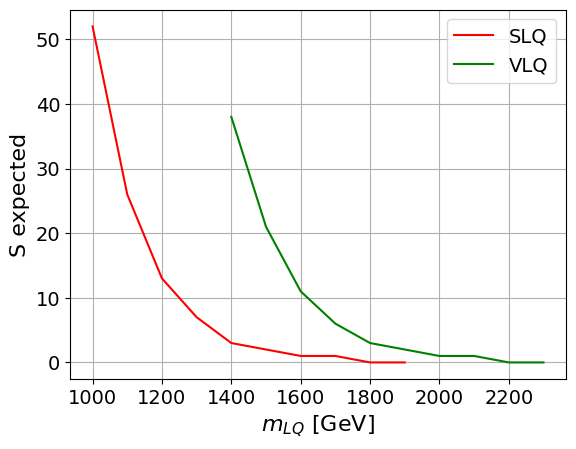

In [19]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
# plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [20]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (52 ev)  -> VLQ 1400 GeV (38 ev)
SLQ 1100 GeV (26 ev)  -> VLQ 1500 GeV (21 ev)
SLQ 1200 GeV (13 ev)  -> VLQ 1600 GeV (11 ev)
SLQ 1300 GeV (7 ev)  -> VLQ 1700 GeV (6 ev)
SLQ 1400 GeV (3 ev)  -> VLQ 1800 GeV (3 ev)
SLQ 1500 GeV (2 ev)  -> VLQ 1900 GeV (2 ev)
SLQ 1600 GeV (1 ev)  -> VLQ 2000 GeV (1 ev)
SLQ 1700 GeV (1 ev)  -> VLQ 2000 GeV (1 ev)
SLQ 1800 GeV (0 ev)  -> VLQ 2200 GeV (0 ev)
SLQ 1900 GeV (0 ev)  -> VLQ 2200 GeV (0 ev)


### Plot

In [21]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'darkorange', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    # plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        # plt.ylim(1e-2,1e-0)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    plt.show()

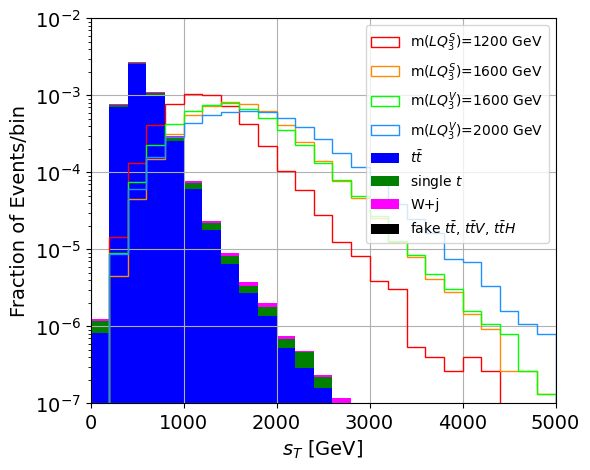

In [22]:
# Ejemple: sT
plot_variable('sT', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET
              range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              )

# 1. DATA FORMAT for CLASSIFIERS

In [23]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [24]:
# DATA WITH UNCERTAINTIES

factor_down = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_down = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_down.columns:
    df_B_all_down["sT"] = df_B_all_down["sT"] * (1 - factor_down)



df_SLQ_all_down = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_SLQ_all_down[key] = df_sample



df_VLQ_all_down = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_VLQ_all_down[key] = df_sample

In [25]:
# DATA WITH UNCERTAINTIES

factor_up = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_up = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_up.columns:
    df_B_all_up["sT"] = df_B_all_up["sT"] * (1 + factor_up)



df_SLQ_all_up = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_SLQ_all_up[key] = df_sample



df_VLQ_all_up = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_VLQ_all_up[key] = df_sample

In [26]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features_13TeV.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (300000, 53)
X_val_SM :  (75000, 53)
X_test_SM :  (187500, 53)
X_pseudo_SM :  (187500, 53)

X_train_SLQ1200 :  (15000, 53)
X_val_SLQ1200 :  (3750, 53)
X_test_SLQ1200 :  (9375, 53)
X_pseudo_SLQ1200 :  (9375, 53)

X_train_VLQ1600 :  (15000, 53)
X_val_VLQ1600 :  (3750, 53)
X_test_VLQ1600 :  (9375, 53)
X_pseudo_VLQ1600 :  (9375, 53)


In [27]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

In [28]:

# Apply normalization
df_SM_down_norm = pd.DataFrame(scaler.transform(df_B_all_down), columns=df_B_all_down.columns)
df_SLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_down[mass]), columns=df_SLQ_all_down[mass].columns) for mass in df_SLQ_all_down}
df_VLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_down[mass]), columns=df_VLQ_all_down[mass].columns) for mass in df_VLQ_all_down}

# to save memory
del df_B_all_down
del df_SLQ_all_down
del df_VLQ_all_down

In [29]:

# Apply normalization
df_SM_up_norm = pd.DataFrame(scaler.transform(df_B_all_up), columns=df_B_all_up.columns)
df_SLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_up[mass]), columns=df_SLQ_all_up[mass].columns) for mass in df_SLQ_all_up}
df_VLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_up[mass]), columns=df_VLQ_all_up[mass].columns) for mass in df_VLQ_all_up}

# to save memory
del df_B_all_up
del df_SLQ_all_up
del df_VLQ_all_up

# SM vs LQ

In [30]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test



# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

750000 750000 750000
(843750, 53)
(281250, 53)
(375000, 53)


In [31]:
# Combine all LQ in a single DataFrame
df_LQ_down_list = list(df_SLQ_down_norm.values()) + list(df_VLQ_down_norm.values())
df_LQ_down_norm = pd.concat(df_LQ_down_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_down_norm), len(df_LQ_down_norm))


# Create X, y
X_test_down = pd.concat([df_SM_down_norm, df_LQ_down_norm], ignore_index=True)
y_test_down = np.hstack([np.zeros(len(df_SM_down_norm)), np.ones(len(df_LQ_down_norm))])  # 0=SM, 1=LQ


print(X_test_down.shape)
print(y_test_down.shape)

400000 400000
(800000, 53)
(800000,)


In [32]:
# Combine all LQ in a single DataFrame
df_LQ_up_list = list(df_SLQ_up_norm.values()) + list(df_VLQ_up_norm.values())
df_LQ_up_norm = pd.concat(df_LQ_up_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_up_norm), len(df_LQ_up_norm))


# Create X, y
X_test_up = pd.concat([df_SM_up_norm, df_LQ_up_norm], ignore_index=True)
y_test_up = np.hstack([np.zeros(len(df_SM_up_norm)), np.ones(len(df_LQ_up_norm))])  # 0=SM, 1=LQ


print(X_test_up.shape)
print(y_test_up.shape)

400000 400000
(800000, 53)
(800000,)


In [ ]:
# # Train
# xgb_clf = XGBClassifier(
#     n_estimators=1200,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     early_stopping_rounds=50,
#     tree_method='hist'
# )

# xgb_clf.fit(X_train, y_train,
#             eval_set=[(X_train, y_train),
#                       (X_val, y_val)],
#             verbose=True)

# # SAVE
# xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_13TeV.json")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:30:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65164	validation_1-logloss:0.65169
[1]	validation_0-logloss:0.61253	validation_1-logloss:0.61261
[2]	validation_0-logloss:0.57824	validation_1-logloss:0.57836
[3]	validation_0-logloss:0.54705	validation_1-logloss:0.54719
[4]	validation_0-logloss:0.51695	validation_1-logloss:0.51713
[5]	validation_0-logloss:0.48921	validation_1-logloss:0.48943
[6]	validation_0-logloss:0.46378	validation_1-logloss:0.46402
[7]	validation_0-logloss:0.44028	validation_1-logloss:0.44057
[8]	validation_0-logloss:0.41937	validation_1-logloss:0.41968
[9]	validation_0-logloss:0.39917	validation_1-logloss:0.39952
[10]	validation_0-logloss:0.38037	validation_1-logloss:0.38075
[11]	validation_0-logloss:0.36291	validation_1-logloss:0.36331
[12]	validation_0-logloss:0.34660	validation_1-logloss:0.34702
[13]	validation_0-logloss:0.33218	validation_1-logloss:0.33261
[14]	validation_0-logloss:0.31790	validation_1-logloss:0.31835
[15]	validation_0-logloss:0.30454	validation_1-logloss:0.30502
[1

Accuracy: 0.974, ROC-AUC: 0.99662


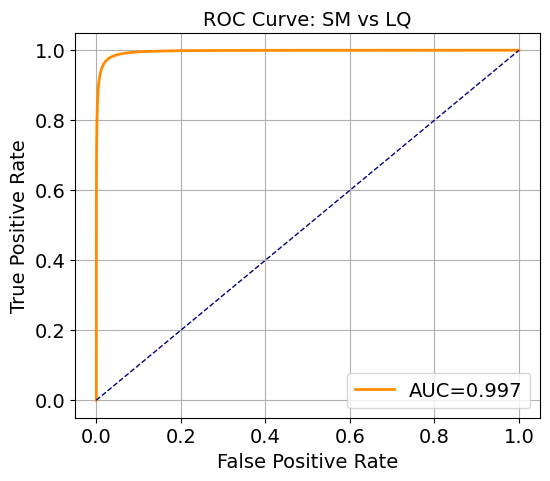

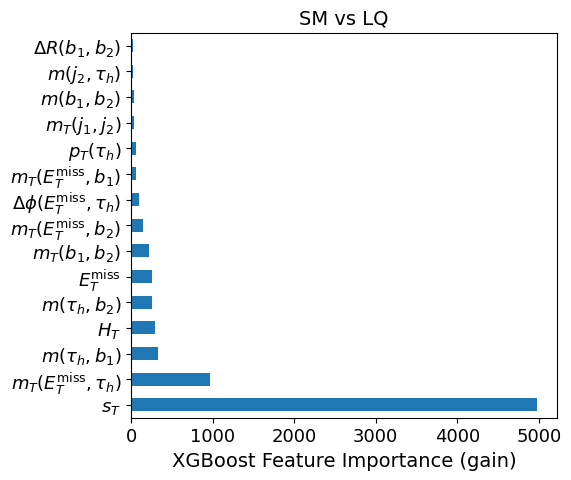

[52, 47, 35, 17, 36, 15, 50, 46, 32, 45, 6, 51, 37, 43, 22]


In [33]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_13TeV.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Accuracy: 0.976, ROC-AUC: 0.99735
Accuracy: 0.976, ROC-AUC: 0.99733


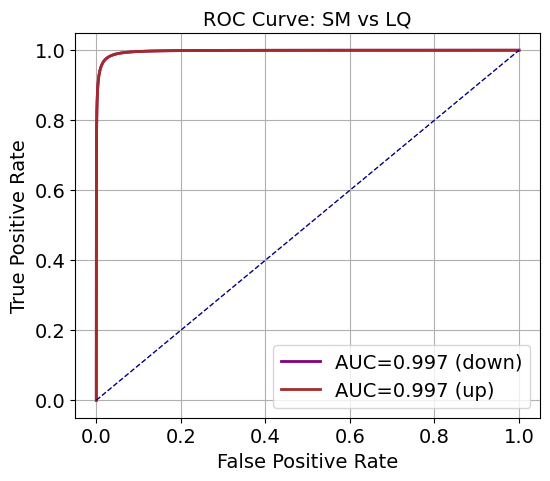

In [34]:

# Evaluate
y_pred_down = xgb_clf.predict(X_test_down)
y_pred_proba_down = xgb_clf.predict_proba(X_test_down)[:,1]

acc_down = accuracy_score(y_test_down, y_pred_down)
auc_down = roc_auc_score(y_test_down, y_pred_proba_down)
print(f"Accuracy: {acc_down:.3f}, ROC-AUC: {auc_down:.5f}")


# Evaluate
y_pred_up = xgb_clf.predict(X_test_up)
y_pred_proba_up = xgb_clf.predict_proba(X_test_up)[:,1]

acc_up = accuracy_score(y_test_up, y_pred_up)
auc_up = roc_auc_score(y_test_up, y_pred_proba_up)
print(f"Accuracy: {acc_up:.3f}, ROC-AUC: {auc_up:.5f}")

# ROC curve
fpr_down, tpr_down, _ = roc_curve(y_test_down, y_pred_proba_down)
fpr_up, tpr_up, _ = roc_curve(y_test_up, y_pred_proba_up)

plt.figure(figsize=(6,5))
plt.plot(fpr_down, tpr_down, color='purple', lw=2, label=f'AUC={auc_down:.3f} (down)')
plt.plot(fpr_up, tpr_up, color='brown', lw=2, label=f'AUC={auc_up:.3f} (up)')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


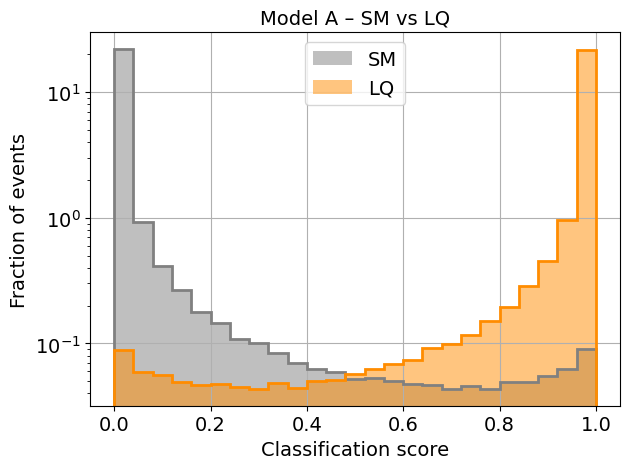

In [35]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

# Exclusion and Discovery

In [36]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in masses_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [38]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_down = xgb_clf.predict_proba( df_SM_down_norm )[:,1]

scoresA_SLQ_down = {}
scoresA_VLQ_down = {}

for m in masses_SLQ:
    scoresA_SLQ_down[m] = xgb_clf.predict_proba( df_SLQ_down_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_down[m] = xgb_clf.predict_proba( df_VLQ_down_norm[m] )[:,1]

In [39]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_up = xgb_clf.predict_proba( df_SM_up_norm )[:,1]

scoresA_SLQ_up = {}
scoresA_VLQ_up = {}

for m in masses_SLQ:
    scoresA_SLQ_up[m] = xgb_clf.predict_proba( df_SLQ_up_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_up[m] = xgb_clf.predict_proba( df_VLQ_up_norm[m] )[:,1]

#### Aux functions

In [40]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB




In [41]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )

## Z-Loop for beta=0.5

B_expected:  1428
S_expected:  52
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  10.450927690389136
Z_asimov_dis_VLQ =  11.811511142678162

Z_asimov_exc_SLQ =  7.5591937700987994
Z_asimov_exc_VLQ =  8.233866862159644


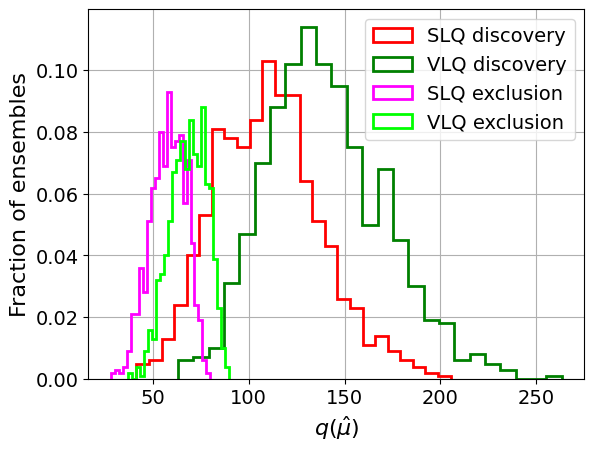


 Binned Likelihood:
Z_dis_SLQ =  10.484765108811201  +-  1.3127832933598973
Z_dis_VLQ =  11.706382835156758  +-  1.3209837290224766

Z_exc_SLQ =  7.623325375925185  +-  0.6090823833930853
Z_exc_VLQ =  8.291977656045692  +-  0.5767633495778247

------------------------------------------

B_expected:  1428
S_expected:  26
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  6.513460699661569
Z_asimov_dis_VLQ =  7.043325299265486

Z_asimov_exc_SLQ =  5.037263798538984
Z_asimov_exc_VLQ =  5.351724481380095


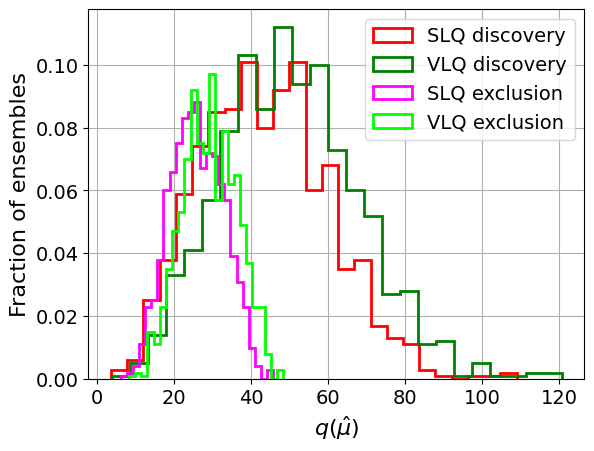


 Binned Likelihood:
Z_dis_SLQ =  6.543262765051268  +-  1.2604463693742451
Z_dis_VLQ =  7.010051877179933  +-  1.265119284212005

Z_exc_SLQ =  5.07113877954163  +-  0.6731837882738289
Z_exc_VLQ =  5.393903233150569  +-  0.6561820501356169

------------------------------------------

B_expected:  1428
S_expected:  13
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.8597193893530934
Z_asimov_dis_VLQ =  4.0606648007686665

Z_asimov_exc_SLQ =  3.2050728842998883
Z_asimov_exc_VLQ =  3.343841771698184


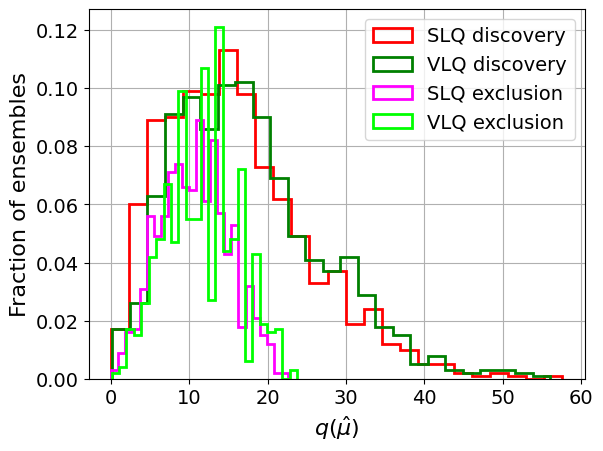


 Binned Likelihood:
Z_dis_SLQ =  3.828557999164589  +-  1.1962465614859417
Z_dis_VLQ =  4.05453252614708  +-  1.1691641309054608

Z_exc_SLQ =  3.268992990423118  +-  0.6672047593495106
Z_exc_VLQ =  3.4056058040458423  +-  0.6640879997840771

------------------------------------------

B_expected:  1428
S_expected:  7
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.3386916033270073
Z_asimov_dis_VLQ =  2.407298554812501

Z_asimov_exc_SLQ =  2.0545254566571978
Z_asimov_exc_VLQ =  2.1076218404621727


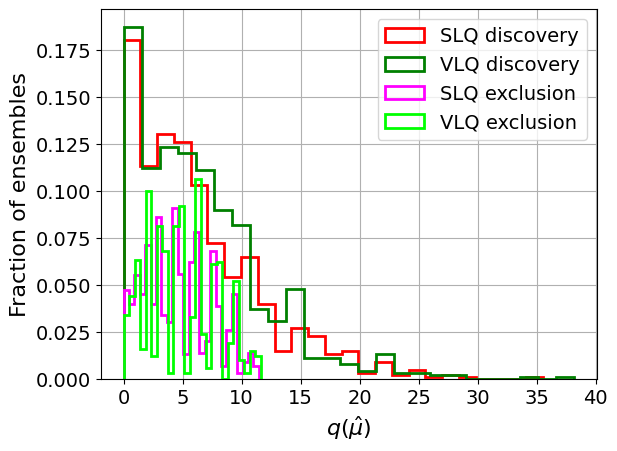


 Binned Likelihood:
Z_dis_SLQ =  2.246884590491277  +-  1.20353004427992
Z_dis_VLQ =  2.2736928859367436  +-  1.1911455497589276

Z_exc_SLQ =  2.100594843190101  +-  0.6677899851132036
Z_exc_VLQ =  2.1566616212818035  +-  0.6672452933725528

------------------------------------------

B_expected:  1428
S_expected:  3
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.109538538522325
Z_asimov_dis_VLQ =  1.1230607331543239

Z_asimov_exc_SLQ =  1.0342799163901737
Z_asimov_exc_VLQ =  1.046009831175566


/tmp/ipykernel_2021/2567009407.py:167: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion


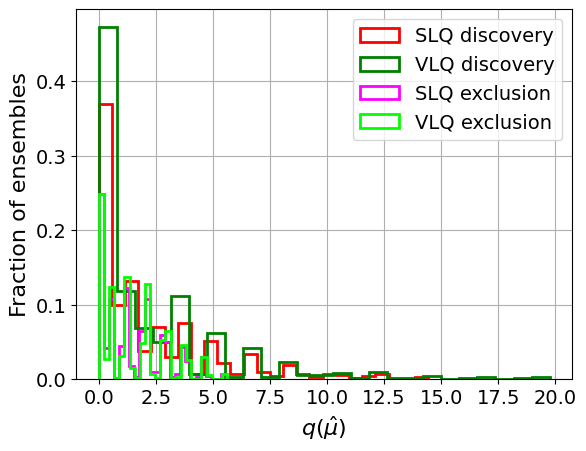


 Binned Likelihood:
Z_dis_SLQ =  1.1203542106670834  +-  1.1964104080208195
Z_dis_VLQ =  1.129731999999058  +-  1.351066195094964

Z_exc_SLQ =  1.1046416705654871  +-  0.6077263082512294
Z_exc_VLQ =  1.1130070178521003  +-  0.6105371361060915

------------------------------------------

B_expected:  1428
S_expected:  2
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7729243895144848
Z_asimov_dis_VLQ =  0.7710473616614407

Z_asimov_exc_SLQ =  0.7344704393972961
Z_asimov_exc_VLQ =  0.7327645530386807


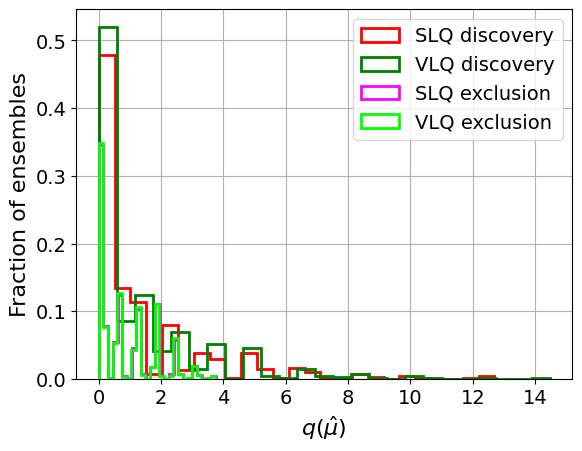


 Binned Likelihood:
Z_dis_SLQ =  0.7378595949513596  +-  1.4409786511032439
Z_dis_VLQ =  0.745023309847734  +-  1.394631663226018

Z_exc_SLQ =  0.7883284373448861  +-  0.5712648360315911
Z_exc_VLQ =  0.7876275827024254  +-  0.5702636422120181

------------------------------------------

B_expected:  1428
S_expected:  1
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4030841058990185
Z_asimov_dis_VLQ =  0.39592208265816425

Z_asimov_exc_SLQ =  0.39197587515896976
Z_asimov_exc_VLQ =  0.3851975133190254


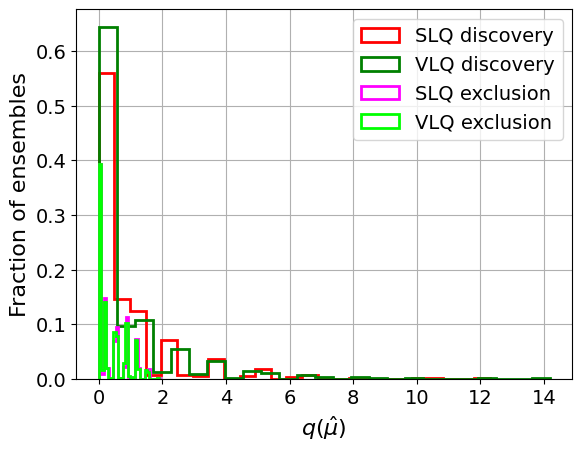


 Binned Likelihood:
Z_dis_SLQ =  0.3771264648384692  +-  1.9560978633029906
Z_dis_VLQ =  0.362433434267483  +-  2.1259006870665935

Z_exc_SLQ =  0.4546495886470913  +-  0.5023644687820628
Z_exc_VLQ =  0.44792377316838106  +-  0.5003620618395317

------------------------------------------

B_expected:  1428
S_expected:  1
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4075760591493606
Z_asimov_dis_VLQ =  0.396965651480228

Z_asimov_exc_SLQ =  0.3962222133572216
Z_asimov_exc_VLQ =  0.38618529250580597


/tmp/ipykernel_2021/2567009407.py:160: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion


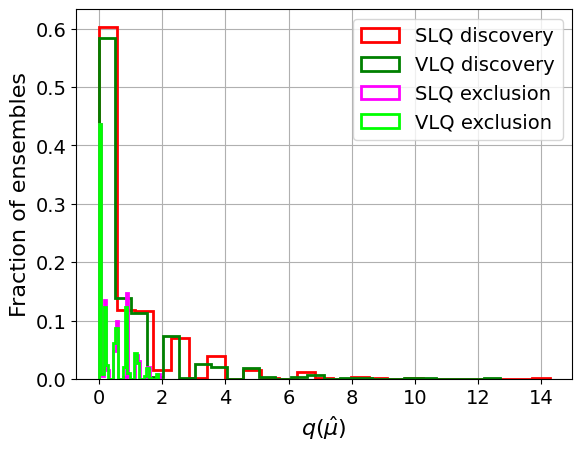


 Binned Likelihood:
Z_dis_SLQ =  0.3631770494877466  +-  2.05255572229137
Z_dis_VLQ =  0.35955115102928736  +-  2.1425920785587667

Z_exc_SLQ =  0.4492927653262055  +-  0.5145618802735961
Z_exc_VLQ =  0.4369872602961733  +-  0.514467067177371

------------------------------------------

B_expected:  1428
S_expected:  0
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV
B_expected:  1428
S_expected:  0
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV


In [42]:

S_expected = S_expected_SLQ

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



Z_asimov_dis_SLQ = []
Z_asimov_exc_SLQ = []

Z_asimov_dis_VLQ = []
Z_asimov_exc_VLQ = []


Z_dis_SLQ = []
Z_exc_SLQ = []

Z_dis_VLQ = []
Z_exc_VLQ = []

Z_dis_std_SLQ = []
Z_exc_std_SLQ = []

Z_dis_std_VLQ = []
Z_exc_std_VLQ = []



for m_it in range(len(masses_SLQ)):

    print('B_expected: ', B_expected)
    print('S_expected: ', S_expected[m_it])

    mass_SLQ = masses_SLQ[m_it]
    mass_VLQ = masses_VLQ[m_it]

    print('m_SLQ= ', mass_SLQ, ' GeV' )
    print('m_VLQ= ', mass_VLQ, ' GeV' )

    if S_expected[m_it] == 0:

        Z_asimov_dis_SLQ.append(0)
        Z_asimov_exc_SLQ.append(0)

        Z_asimov_dis_VLQ.append(0)
        Z_asimov_exc_VLQ.append(0)

        Z_dis_SLQ.append(0)
        Z_dis_std_SLQ.append(1)
        Z_exc_SLQ.append(0)
        Z_exc_std_SLQ.append(1)

        Z_dis_VLQ.append(0)
        Z_dis_std_VLQ.append(1)
        Z_exc_VLQ.append(0)
        Z_exc_std_VLQ.append(1)

        continue


    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
    S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected[m_it])

    # VLQ PDF
    hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
    S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected[m_it])


    Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
    Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

    Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
    Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


    Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
    Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

    Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
    Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


    print('\n Asimov datasets:')
    print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
    print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
    print()
    print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
    print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis_SLQ = []
    q_exc_SLQ = []

    q_dis_VLQ = []
    q_exc_VLQ = []


    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_expected[m_it])


        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        # SLQ
        scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
        N_pseudo_SLQ = hist

        # VLQ
        scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
        N_pseudo_VLQ = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        # SLQ and VLQ (since no signal)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        # SLQ
        mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
        q_dis_SLQ.append(q_dis_SLQ_it)


        # VLQ
        mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
        q_dis_VLQ.append(q_dis_VLQ_it)



        # EXCLUSION (mu_hat=0 idedally)
        # SLQ
        mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
        q_exc_SLQ.append(q_exc_SLQ_it)


        # VLQ
        mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
        q_exc_VLQ.append(q_exc_VLQ_it)




    # Histogram of q_muhats
    weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
    weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

    weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
    weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
    Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

    Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
    Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


    Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
    Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

    Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
    Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


    Z_dis_SLQ.append(Z_dis_SLQ_it)
    Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
    Z_exc_SLQ.append(Z_exc_SLQ_it)
    Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

    Z_dis_VLQ.append(Z_dis_VLQ_it)
    Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
    Z_exc_VLQ.append(Z_exc_VLQ_it)
    Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


    print('\n Binned Likelihood:')
    print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
    print()
    print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
    print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)


    print('\n------------------------------------------\n')

m_asimov_dis_SLQ =  1157.0312069900153  GeV
m_asimov_dis_VLQ =  1568.5068012365225  GeV

m_asimov_exc_SLQ =  1340.1542387138006  GeV
m_asimov_exc_VLQ =  1743.5910869001639  GeV

m_BL_dis_SLQ =  1156.8482725799174  GeV
m_BL_dis_VLQ =  1568.010107139968  GeV

m_BL_exc_SLQ =  1345.7593016183305  GeV
m_BL_exc_VLQ =  1749.0399786144194  GeV


/tmp/ipykernel_2021/2666492215.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_2021/2666492215.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_2021/2666492215.py:24: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_2021/2666492215.py:25: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_2021/2666492215.py:28: RuntimeWarning

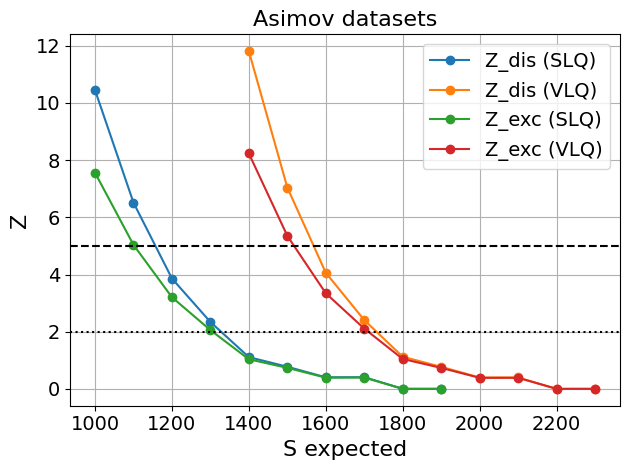

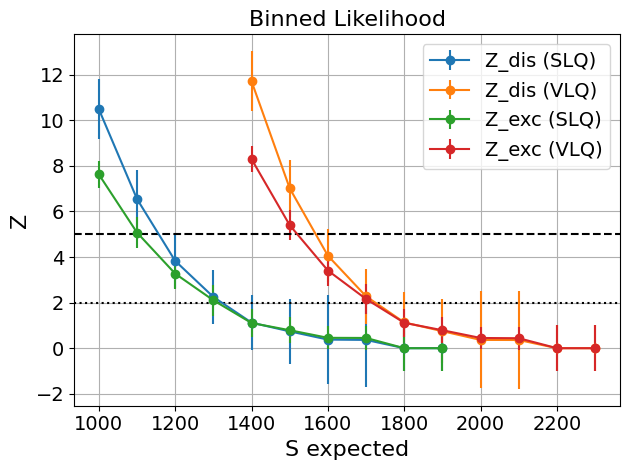

In [43]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)

#  interpolate
f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")


# find the mass such that we get Z for discovery or exclusion

m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]

m_BL_dis_SLQ = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
m_BL_exc_VLQ = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1600)[0]



print(r'm_asimov_dis_SLQ = ', m_asimov_dis_SLQ, ' GeV')
print(r'm_asimov_dis_VLQ = ', m_asimov_dis_VLQ, ' GeV')
print()
print(r'm_asimov_exc_SLQ = ', m_asimov_exc_SLQ, ' GeV')
print(r'm_asimov_exc_VLQ = ', m_asimov_exc_VLQ, ' GeV')

print()
print(r'm_BL_dis_SLQ = ', m_BL_dis_SLQ, ' GeV')
print(r'm_BL_dis_VLQ = ', m_BL_dis_VLQ, ' GeV')
print()
print(r'm_BL_exc_SLQ = ', m_BL_exc_SLQ, ' GeV')
print(r'm_BL_exc_VLQ = ', m_BL_exc_VLQ, ' GeV')





# plot ASIMOV DATASETS

plt.plot(masses_SLQ, Z_asimov_dis_SLQ, 'o-', label='Z_dis (SLQ)')
plt.plot(masses_VLQ, Z_asimov_dis_VLQ, 'o-', label='Z_dis (VLQ)')

plt.plot(masses_SLQ, Z_asimov_exc_SLQ, 'o-', label='Z_exc (SLQ)')
plt.plot(masses_VLQ, Z_asimov_exc_VLQ, 'o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.errorbar(masses_SLQ, Z_dis_SLQ, yerr=Z_dis_std_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_dis_VLQ, yerr=Z_dis_std_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_exc_SLQ, yerr=Z_exc_std_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_exc_VLQ, yerr=Z_exc_std_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Z-Loop for all betas

In [44]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)
Z_exc

np.float64(1.6448536269514729)

<>:227: SyntaxWarning: invalid escape sequence '\h'
<>:227: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3797/2223093852.py:227: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$q(\hat{\mu})$",fontsize=16)


beta:  0.0
B_expected:  45962
S_expected_SLQ:  306.8637905250077
S_expected_VLQ:  316.0401052807328
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.546250309217704
Z_asimov_dis_VLQ =  17.45254093612667

Z_asimov_exc_SLQ =  12.736026555357713
Z_asimov_exc_VLQ =  14.90646539444877


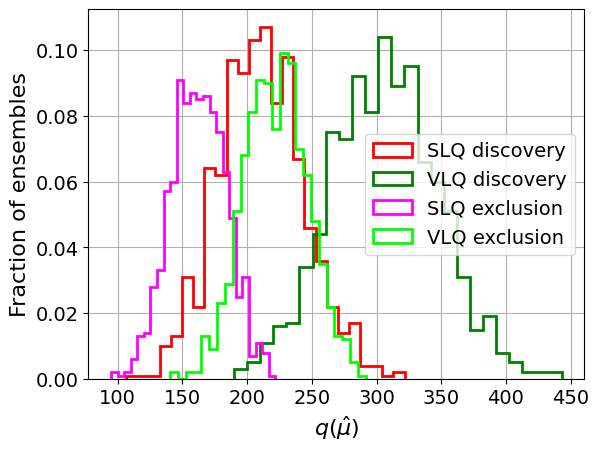


 Binned Likelihood:
Z_dis_SLQ =  14.497342374936956  +-  1.1208660277182356
Z_dis_VLQ =  17.487715510300216  +-  1.1800250804193912

Z_exc_SLQ =  12.737999088583228  +-  0.830003087139152
Z_exc_VLQ =  14.913096344374091  +-  0.81551036352781

------------------------------------------

B_expected:  45962
S_expected_SLQ:  173.4030038499535
S_expected_VLQ:  182.19533570545943
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  9.481097605477373
Z_asimov_dis_VLQ =  10.91631188846309

Z_asimov_exc_SLQ =  8.606986293981766
Z_asimov_exc_VLQ =  9.777218801905303


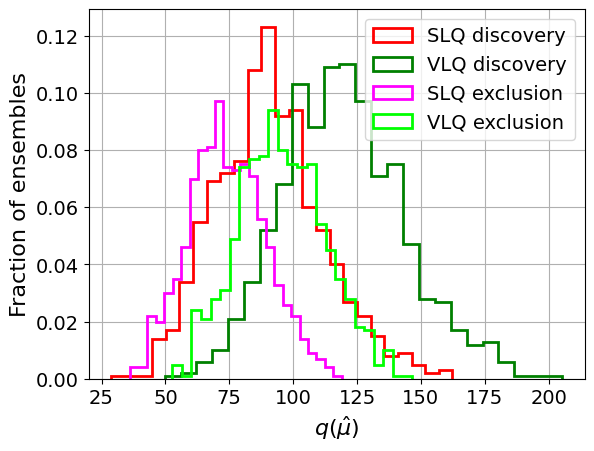


 Binned Likelihood:
Z_dis_SLQ =  9.474415442648095  +-  1.1079068535699568
Z_dis_VLQ =  10.893735285283041  +-  1.0852519355902375

Z_exc_SLQ =  8.547730186731535  +-  0.8810868332460815
Z_exc_VLQ =  9.744828332803692  +-  0.8666163364787987

------------------------------------------

B_expected:  45962
S_expected_SLQ:  97.98680285068228
S_expected_VLQ:  105.03458199818786
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.9058779372723835
Z_asimov_dis_VLQ =  6.683784481168506

Z_asimov_exc_SLQ =  5.5327100384557415
Z_asimov_exc_VLQ =  6.211785469674719


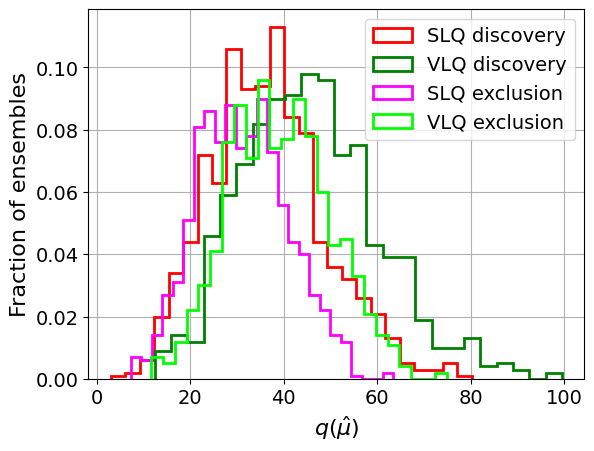


 Binned Likelihood:
Z_dis_SLQ =  5.973618223735842  +-  1.035380016922222
Z_dis_VLQ =  6.6791372349822895  +-  1.0948291079869874

Z_exc_SLQ =  5.547308191886019  +-  0.8640372871024785
Z_exc_VLQ =  6.229330182748772  +-  0.8643558052717314

------------------------------------------

B_expected:  45962
S_expected_SLQ:  55.37051446471266
S_expected_VLQ:  61.53409378214107
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.569463600540688
Z_asimov_dis_VLQ =  4.079219863240334

Z_asimov_exc_SLQ =  3.4236756516238045
Z_asimov_exc_VLQ =  3.8909112253120255


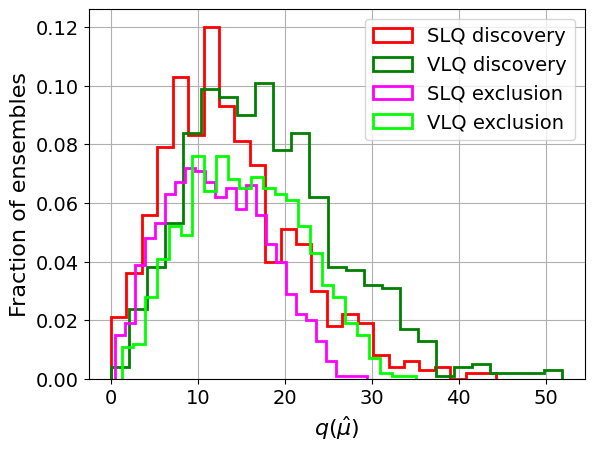


 Binned Likelihood:
Z_dis_SLQ =  3.526841710190566  +-  1.0795342959836003
Z_dis_VLQ =  4.095343989478435  +-  1.0564722033171579

Z_exc_SLQ =  3.437192080582084  +-  0.8356969308000575
Z_exc_VLQ =  3.9026796676400504  +-  0.8441349574477207

------------------------------------------

B_expected:  45962
S_expected_SLQ:  31.288844853514952
S_expected_VLQ:  36.04950508257041
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.11446041170524
Z_asimov_dis_VLQ =  2.459500398320034

Z_asimov_exc_SLQ =  2.0610032266124336
Z_asimov_exc_VLQ =  2.3878065055122297


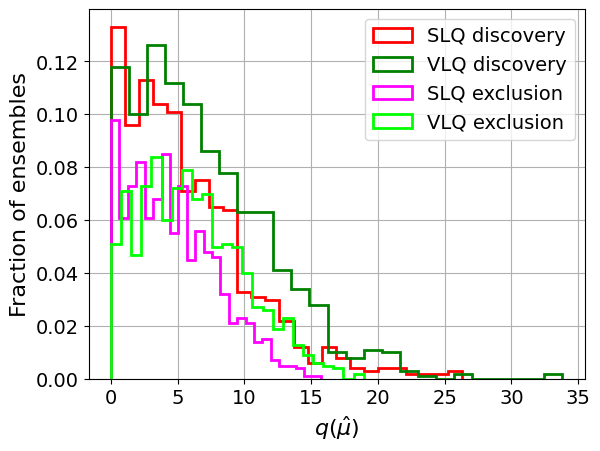


 Binned Likelihood:
Z_dis_SLQ =  2.1806900616580553  +-  1.0770539936553596
Z_dis_VLQ =  2.4404600434439154  +-  1.039906664669847

Z_exc_SLQ =  2.046608526537262  +-  0.796460773981284
Z_exc_VLQ =  2.372318852429534  +-  0.8112293788608645

------------------------------------------

B_expected:  45962
S_expected_SLQ:  18.144071209400828
S_expected_VLQ:  21.546825381336397
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.268694399719795
Z_asimov_dis_VLQ =  1.4994436861529359

Z_asimov_exc_SLQ =  1.248928285612461
Z_asimov_exc_VLQ =  1.4720213799406014


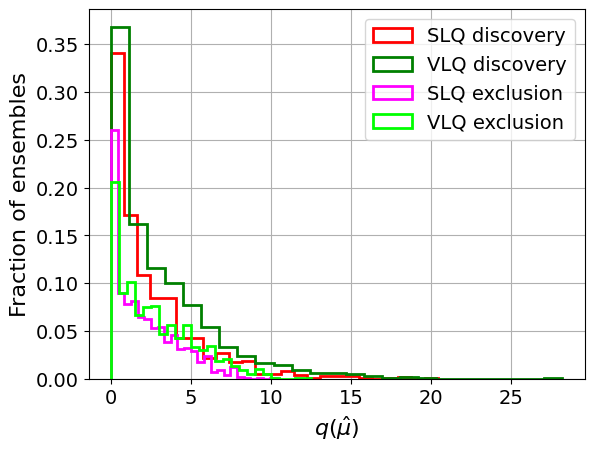


 Binned Likelihood:
Z_dis_SLQ =  1.253061654381423  +-  1.1801143626746828
Z_dis_VLQ =  1.421880979797935  +-  1.2103090569091548

Z_exc_SLQ =  1.2645376930430792  +-  0.7875809945394774
Z_exc_VLQ =  1.4878431678177586  +-  0.8074693714166213

------------------------------------------

B_expected:  45962
S_expected_SLQ:  10.521555576534027
S_expected_VLQ:  12.87855916330652
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7531888840071492
Z_asimov_dis_VLQ =  0.9037341771304919

Z_asimov_exc_SLQ =  0.7461052752912082
Z_asimov_exc_VLQ =  0.8935881160834402


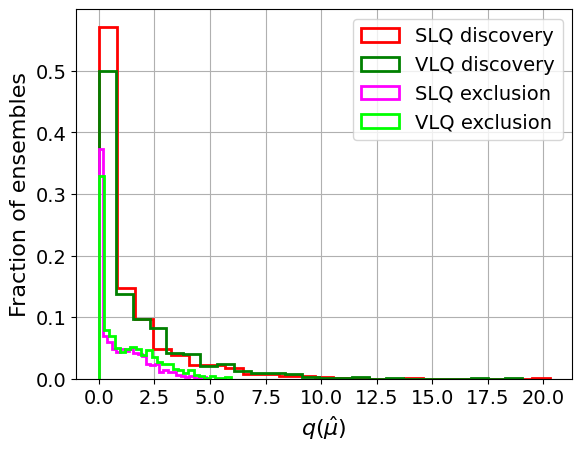


 Binned Likelihood:
Z_dis_SLQ =  0.7152533429682214  +-  1.4422223000232433
Z_dis_VLQ =  0.8817319218213799  +-  1.308155265113176

Z_exc_SLQ =  0.7586565107259813  +-  0.6907472729929552
Z_exc_VLQ =  0.9064870947235203  +-  0.7104461096486923

------------------------------------------

B_expected:  45962
S_expected_SLQ:  6.094178583939264
S_expected_VLQ:  7.845116763707893
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.44281983869943514
Z_asimov_dis_VLQ =  0.5543094483049915

Z_asimov_exc_SLQ =  0.44034650909037565
Z_asimov_exc_VLQ =  0.5504504521851459


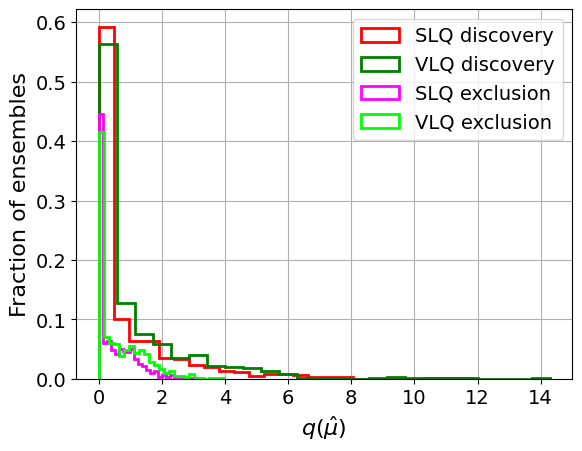


 Binned Likelihood:
Z_dis_SLQ =  0.43854344808263956  +-  1.8688540674905185
Z_dis_VLQ =  0.5530340732264869  +-  1.5923805861996074

Z_exc_SLQ =  0.4890178025173089  +-  0.5985621214392728
Z_exc_VLQ =  0.5981438686935148  +-  0.6255653024868107

------------------------------------------

B_expected:  45962
S_expected_SLQ:  3.5298024463012108
S_expected_VLQ:  4.778939651227949
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.25884186468854814
Z_asimov_dis_VLQ =  0.34086337721527593

Z_asimov_exc_SLQ =  0.25799164670667807
Z_asimov_exc_VLQ =  0.3393938797748722


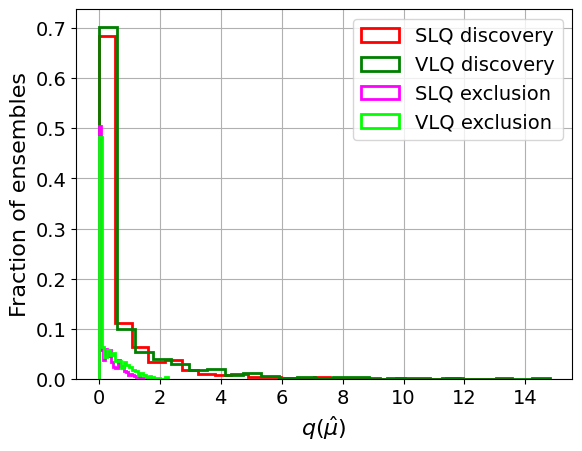


 Binned Likelihood:
Z_dis_SLQ =  0.2756156402374034  +-  2.7547573447011047
Z_dis_VLQ =  0.2462506948775593  +-  3.0672717134082825

Z_exc_SLQ =  0.24949732096205715  +-  0.6583523529567434
Z_exc_VLQ =  0.3355306680780348  +-  0.656557325750779

------------------------------------------

B_expected:  45962
S_expected_SLQ:  2.0832873678051733
S_expected_VLQ:  2.9111439482622186
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.15406879192079947
Z_asimov_dis_VLQ =  0.20725130774752654

Z_asimov_exc_SLQ =  0.15376649999467704
Z_asimov_exc_VLQ =  0.20670576715561656


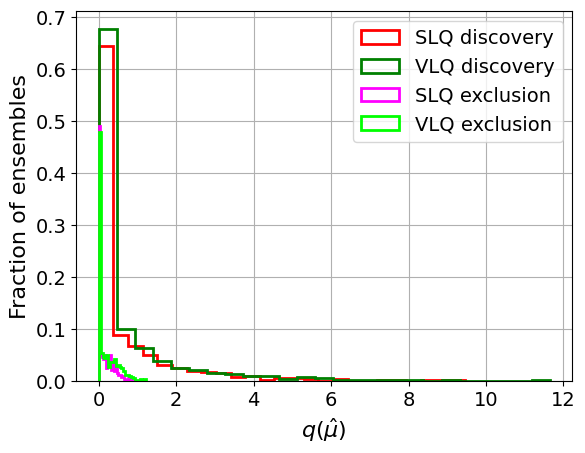


 Binned Likelihood:
Z_dis_SLQ =  0.19153391648717902  +-  3.359255165030411
Z_dis_VLQ =  0.22683780065009057  +-  2.9193801508290353

Z_exc_SLQ =  0.2020703399925069  +-  0.4625518658414316
Z_exc_VLQ =  0.25996830540165494  +-  0.4899899204488325

------------------------------------------

m_asimov_dis_SLQ =  1238.7721442652837  GeV
m_asimov_dis_VLQ =  1664.6474450884575  GeV

m_asimov_exc_VLQ =  1881.1274236515917  GeV
m_asimov_exc_SLQ =  1451.2452211797747  GeV

m_BL_dis_SLQ =  1239.7918738530439  GeV
m_BL_dis_VLQ =  1664.9872909879384  GeV

m_BL_exc_VLQ =  1882.248188179121  GeV
m_BL_exc_SLQ =  1451.3706537029138  GeV

######################################

beta:  0.1
B_expected:  45962
S_expected_SLQ:  1403.5699358705256
S_expected_VLQ:  1445.5416507189457
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  51.302825695653134
Z_asimov_dis_VLQ =  59.65854546555227

Z_asimov_exc_SLQ =  38.05669716786074
Z_asimov_exc_VLQ =  42.525862463971386


/tmp/ipykernel_3797/2223093852.py:313: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_3797/2223093852.py:314: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_3797/2223093852.py:316: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1800)[0]
/tmp/ipykernel_3797/2223093852.py:319: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_3797/2223093852.py:320: R

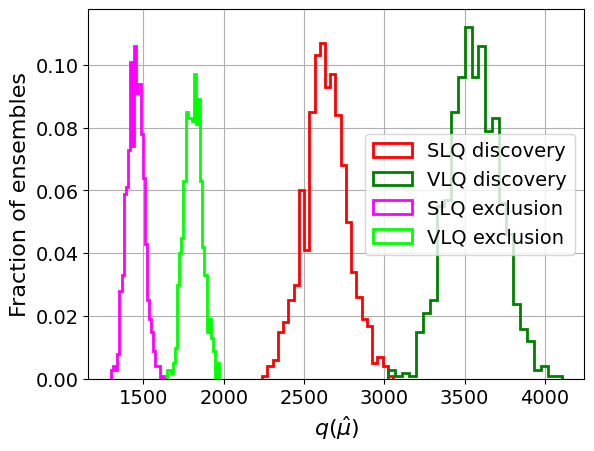


 Binned Likelihood:
Z_dis_SLQ =  51.315775382868516  +-  1.2926979566412893
Z_dis_VLQ =  59.63691593882832  +-  1.3420491152223606

Z_exc_SLQ =  38.04880123775733  +-  0.6813231495224534
Z_exc_VLQ =  42.54106961058841  +-  0.6384673715656397

------------------------------------------

B_expected:  45962
S_expected_SLQ:  793.131188847781
S_expected_VLQ:  833.3465972459873
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  35.064563880629635
Z_asimov_dis_VLQ =  39.566397469464086

Z_asimov_exc_SLQ =  27.385815987124303
Z_asimov_exc_VLQ =  30.163617300435902


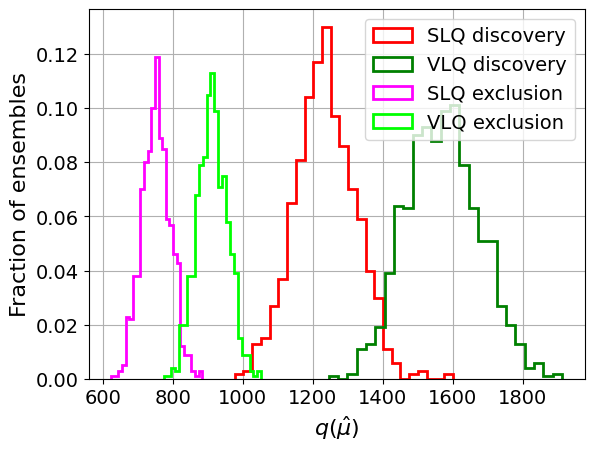


 Binned Likelihood:
Z_dis_SLQ =  35.12068075459588  +-  1.2405099296734718
Z_dis_VLQ =  39.632754306508325  +-  1.316164909944654

Z_exc_SLQ =  27.43960841988884  +-  0.743165847318972
Z_exc_VLQ =  30.197343953760345  +-  0.7170826218587223

------------------------------------------

B_expected:  45962
S_expected_SLQ:  448.1836399074329
S_expected_VLQ:  480.4196065855801
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  22.985322055648453
Z_asimov_dis_VLQ =  25.642600623832582

Z_asimov_exc_SLQ =  18.99674825325335
Z_asimov_exc_VLQ =  20.844247124593252


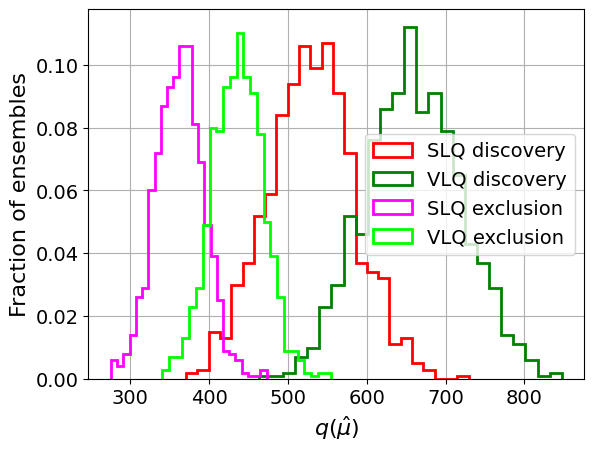


 Binned Likelihood:
Z_dis_SLQ =  22.999665771730506  +-  1.1891181427818083
Z_dis_VLQ =  25.660566069326475  +-  1.1844953108847993

Z_exc_SLQ =  19.05001123428104  +-  0.7941245573400566
Z_exc_VLQ =  20.87562226072119  +-  0.77988586335641

------------------------------------------

B_expected:  45962
S_expected_SLQ:  253.26021458377744
S_expected_VLQ:  281.4519233953483
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.555901922287024
Z_asimov_dis_VLQ =  16.437204803933888

Z_asimov_exc_SLQ =  12.681650530830506
Z_asimov_exc_VLQ =  14.125066821611984


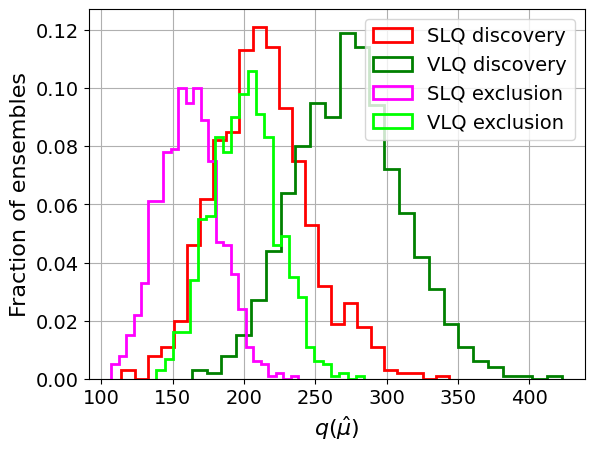


 Binned Likelihood:
Z_dis_SLQ =  14.520657497231275  +-  1.1434509729043898
Z_dis_VLQ =  16.54619950996735  +-  1.1367414238005351

Z_exc_SLQ =  12.69169644250256  +-  0.8205784700195597
Z_exc_VLQ =  14.139524392045125  +-  0.808910127516159

------------------------------------------

B_expected:  45962
S_expected_SLQ:  143.1126229959409
S_expected_VLQ:  164.8874943842033
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.956050643362
Z_asimov_dis_VLQ =  10.314159647323374

Z_asimov_exc_SLQ =  8.153545689466176
Z_asimov_exc_VLQ =  9.2807496402969


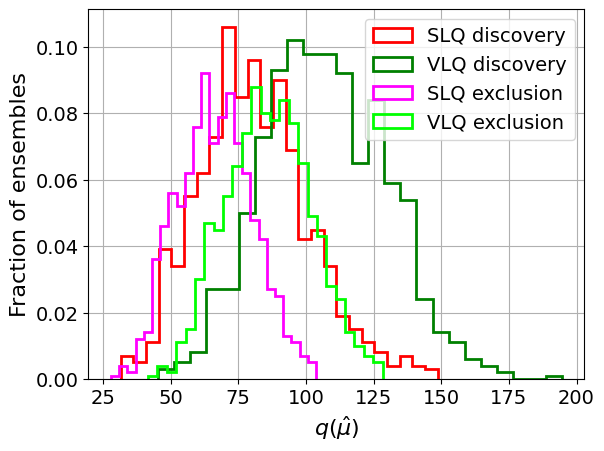


 Binned Likelihood:
Z_dis_SLQ =  8.907541708587292  +-  1.1441561414934047
Z_dis_VLQ =  10.273457447411175  +-  1.093916629199834

Z_exc_SLQ =  8.143699210084328  +-  0.845815957607898
Z_exc_VLQ =  9.27122614460998  +-  0.8395342707348825

------------------------------------------

B_expected:  45962
S_expected_SLQ:  82.98950104291825
S_expected_VLQ:  98.5534209394808
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.519478634119443
Z_asimov_dis_VLQ =  6.472929622320015

Z_asimov_exc_SLQ =  5.187362015164687
Z_asimov_exc_VLQ =  6.027058943152253


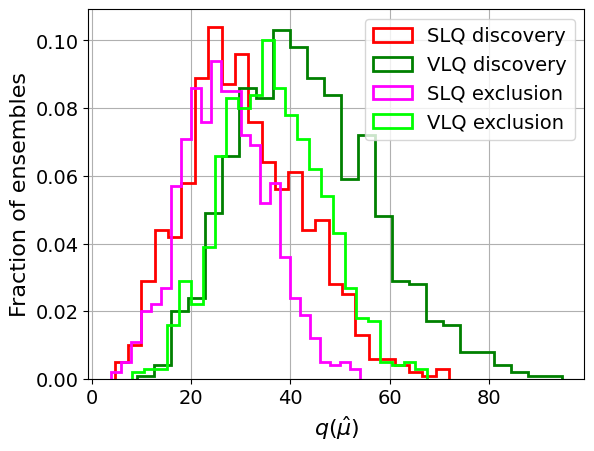


 Binned Likelihood:
Z_dis_SLQ =  5.444872633087112  +-  1.0741703000374412
Z_dis_VLQ =  6.476013870761099  +-  1.0710821851370338

Z_exc_SLQ =  5.162338637297995  +-  0.8426678451410423
Z_exc_VLQ =  6.001530481643461  +-  0.8433923234753972

------------------------------------------

B_expected:  45962
S_expected_SLQ:  48.12473658279519
S_expected_VLQ:  58.905478642563445
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.338404210478358
Z_asimov_dis_VLQ =  3.98312601748467

Z_asimov_exc_SLQ =  3.209441785677973
Z_asimov_exc_VLQ =  3.8028791140359774


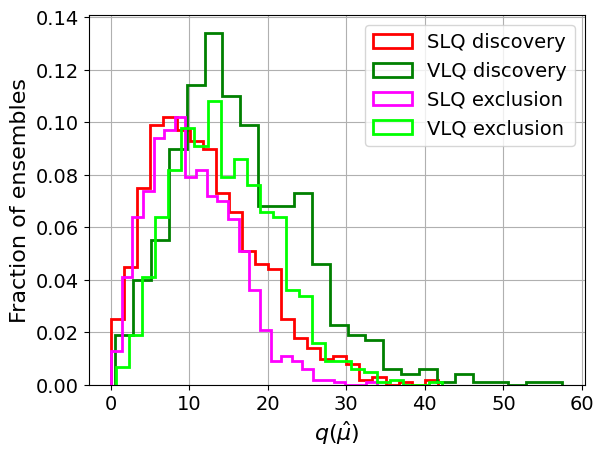


 Binned Likelihood:
Z_dis_SLQ =  3.343973171652101  +-  1.0347090566663306
Z_dis_VLQ =  3.915758450263754  +-  1.0628931855493724

Z_exc_SLQ =  3.125041583817133  +-  0.8636498082773392
Z_exc_VLQ =  3.72205037195615  +-  0.8686174749397366

------------------------------------------

B_expected:  45962
S_expected_SLQ:  27.874275520122318
S_expected_VLQ:  35.88292386695564
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.9869789347513311
Z_asimov_dis_VLQ =  2.47608993123611

Z_asimov_exc_SLQ =  1.9394662722932956
Z_asimov_exc_VLQ =  2.403412174504704


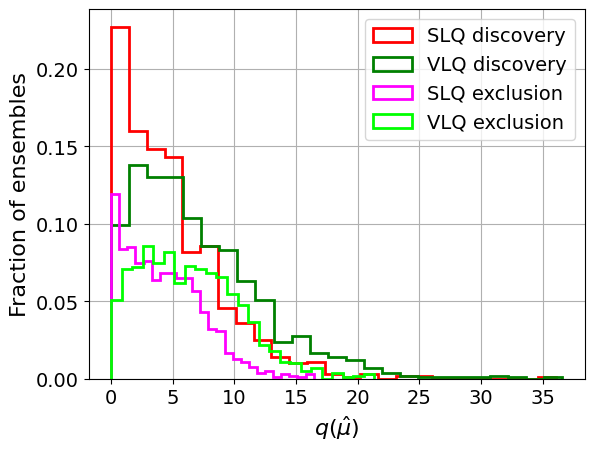


 Binned Likelihood:
Z_dis_SLQ =  2.0020522826888194  +-  1.059508446697049
Z_dis_VLQ =  2.4320929134188263  +-  1.0905148028302216

Z_exc_SLQ =  1.9771550119669696  +-  0.7931096388436328
Z_exc_VLQ =  2.4453185186291853  +-  0.8162324598916831

------------------------------------------

B_expected:  45962
S_expected_SLQ:  16.14502833558287
S_expected_VLQ:  21.858479973565
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.1704364818568715
Z_asimov_dis_VLQ =  1.5359858818475207

Z_asimov_exc_SLQ =  1.1535374600621888
Z_asimov_exc_VLQ =  1.5072247763151085


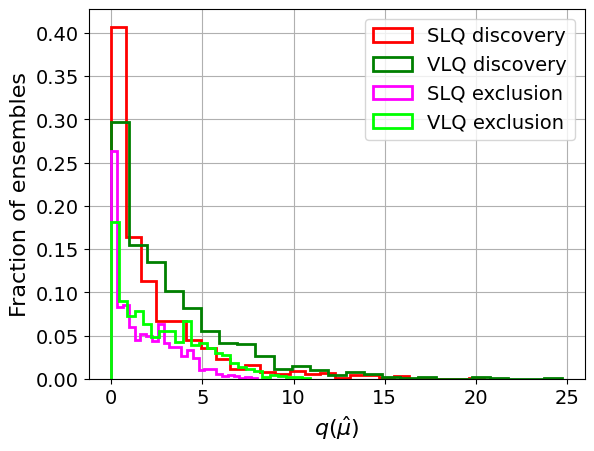


 Binned Likelihood:
Z_dis_SLQ =  1.1010379784379032  +-  1.3064538347782255
Z_dis_VLQ =  1.5322917581249715  +-  1.1017731394354073

Z_exc_SLQ =  1.1641917814077598  +-  0.7222445497857901
Z_exc_VLQ =  1.5084223590756467  +-  0.7614112480218901

------------------------------------------

B_expected:  45962
S_expected_SLQ:  9.528786411154922
S_expected_VLQ:  13.315334851927682
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.6998457961042875
Z_asimov_dis_VLQ =  0.9392470758786466

Z_asimov_exc_SLQ =  0.6937145118183401
Z_asimov_exc_VLQ =  0.9282960197212691


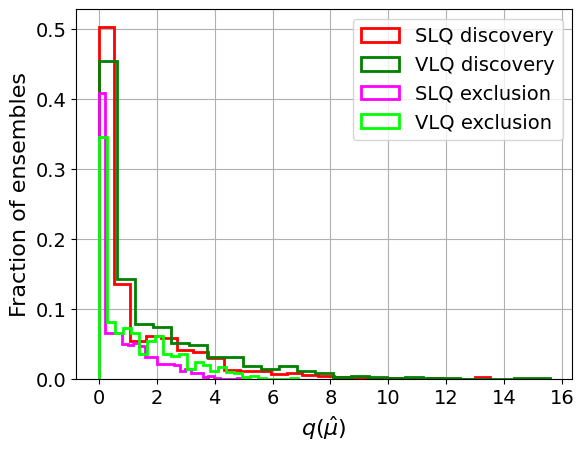


 Binned Likelihood:
Z_dis_SLQ =  0.7331034354072573  +-  1.357545829384519
Z_dis_VLQ =  0.9011733810933797  +-  1.228948231456742

Z_exc_SLQ =  0.6758996005264161  +-  0.7053833118101782
Z_exc_VLQ =  0.9187362939018117  +-  0.724075112445279

------------------------------------------

m_asimov_dis_SLQ =  1523.817556544092  GeV
m_asimov_dis_VLQ =  1959.1584661320073  GeV

m_asimov_exc_VLQ =  2184.642849150257  GeV
m_asimov_exc_SLQ =  1737.4859199404425  GeV

m_BL_dis_SLQ =  1521.1753413836968  GeV
m_BL_dis_VLQ =  1957.6510397729917  GeV

m_BL_exc_VLQ =  2185.4379520628154  GeV
m_BL_exc_SLQ =  1740.8753277546043  GeV

######################################

beta:  0.3
B_expected:  45962
S_expected_SLQ:  2072.5330168824644
S_expected_VLQ:  2134.509098426684
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  69.05575564055212
Z_asimov_dis_VLQ =  79.6529085263193

Z_asimov_exc_SLQ =  48.84322341917858
Z_asimov_exc_VLQ =  53.9715170048295


/tmp/ipykernel_3797/2223093852.py:317: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1800)[0]
/tmp/ipykernel_3797/2223093852.py:323: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1800)[0]


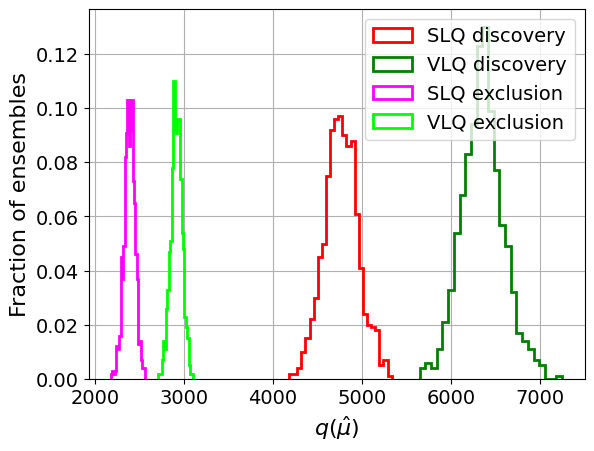


 Binned Likelihood:
Z_dis_SLQ =  68.98603162336802  +-  1.3806529120642343
Z_dis_VLQ =  79.70310807501332  +-  1.4661785431551881

Z_exc_SLQ =  48.84625949107974  +-  0.618340811429593
Z_exc_VLQ =  53.977409140924  +-  0.5805613437322099

------------------------------------------

B_expected:  45962
S_expected_SLQ:  1171.1497472242104
S_expected_VLQ:  1230.5324395736309
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  47.72600383449534
Z_asimov_dis_VLQ =  53.55325116683951

Z_asimov_exc_SLQ =  35.53720018445825
Z_asimov_exc_VLQ =  38.83914967983102


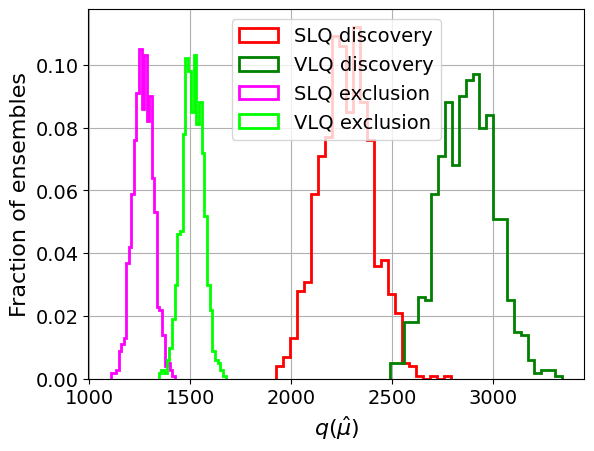


 Binned Likelihood:
Z_dis_SLQ =  47.666121077064865  +-  1.3422669684384934
Z_dis_VLQ =  53.61471127035681  +-  1.3084294555789273

Z_exc_SLQ =  35.56218030074393  +-  0.6877208569520551
Z_exc_VLQ =  38.879195824984066  +-  0.6604702456139047

------------------------------------------

B_expected:  45962
S_expected_SLQ:  661.7948757634273
S_expected_VLQ:  709.3950013889066
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  31.72650967722884
Z_asimov_dis_VLQ =  35.239392603875

Z_asimov_exc_SLQ =  25.07579239163924
Z_asimov_exc_VLQ =  27.343707444872084


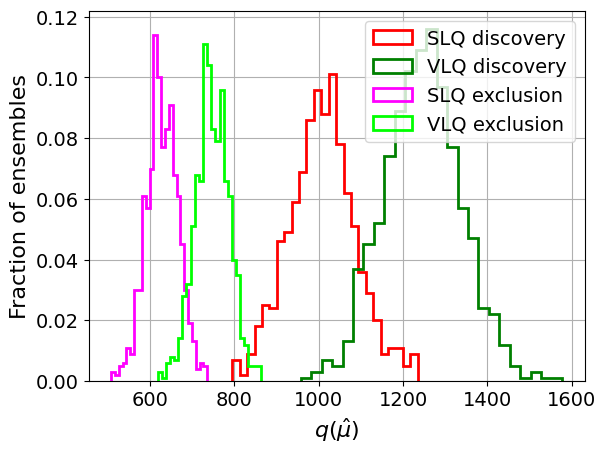


 Binned Likelihood:
Z_dis_SLQ =  31.75624077173829  +-  1.2453576364543186
Z_dis_VLQ =  35.30540743270188  +-  1.289334835686062

Z_exc_SLQ =  25.035422089856002  +-  0.7529545491865388
Z_exc_VLQ =  27.30893258496151  +-  0.7351884490521158

------------------------------------------

B_expected:  45962
S_expected_SLQ:  373.96793930476144
S_expected_VLQ:  415.59625138318904
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  20.39609851728923
Z_asimov_dis_VLQ =  22.936763911118007

Z_asimov_exc_SLQ =  17.095467941029508
Z_asimov_exc_VLQ =  18.923366193636028


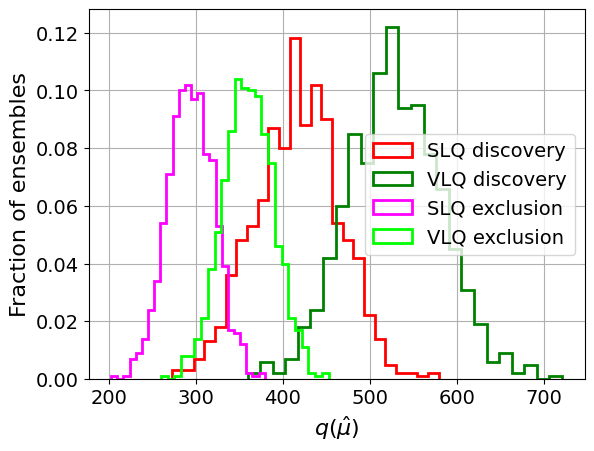


 Binned Likelihood:
Z_dis_SLQ =  20.424429748643938  +-  1.1729398489794192
Z_dis_VLQ =  22.95014039173152  +-  1.1694912599292564

Z_exc_SLQ =  17.140711154220654  +-  0.7732299132362146
Z_exc_VLQ =  18.96671435370715  +-  0.760196631045271

------------------------------------------

B_expected:  45962
S_expected_SLQ:  211.3223065780322
S_expected_VLQ:  243.4754175397265
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  12.7305821087345
Z_asimov_dis_VLQ =  14.602570964761197

Z_asimov_exc_SLQ =  11.238397829465754
Z_asimov_exc_VLQ =  12.709906573050407


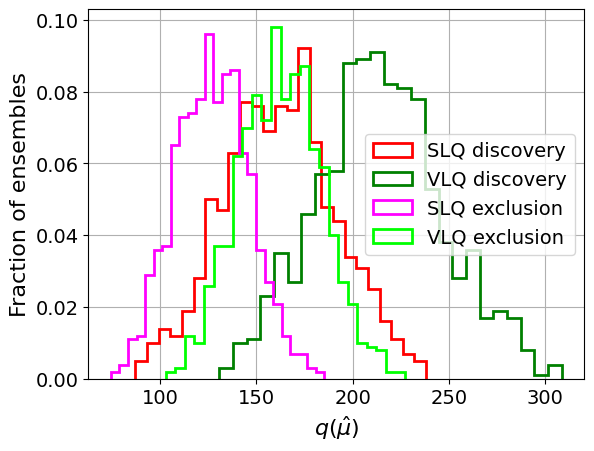


 Binned Likelihood:
Z_dis_SLQ =  12.727705522240012  +-  1.1401106075429945
Z_dis_VLQ =  14.604684165619128  +-  1.1194738965091935

Z_exc_SLQ =  11.262823647458875  +-  0.8544650096524206
Z_exc_VLQ =  12.734356422458951  +-  0.8440348009740386

------------------------------------------

B_expected:  45962
S_expected_SLQ:  122.54357732404156
S_expected_VLQ:  145.52550151133437
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  7.93721253974979
Z_asimov_dis_VLQ =  9.275646097576333

Z_asimov_exc_SLQ =  7.290538617118309
Z_asimov_exc_VLQ =  8.419645750640976


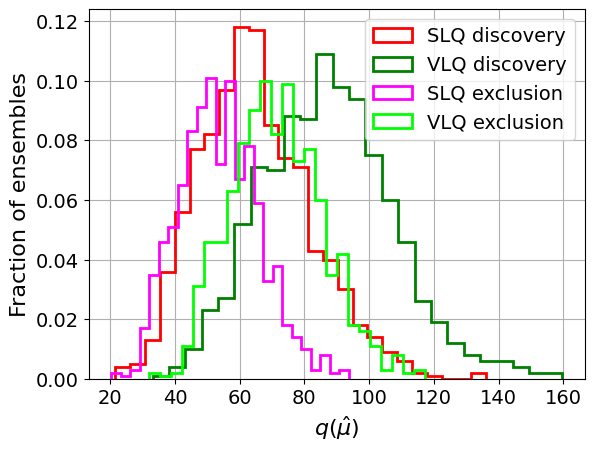


 Binned Likelihood:
Z_dis_SLQ =  7.965761943875116  +-  1.0770176471547934
Z_dis_VLQ =  9.308685480971269  +-  1.0825575123129278

Z_exc_SLQ =  7.27482905112586  +-  0.8386873979120713
Z_exc_VLQ =  8.40324956433074  +-  0.8329806808999083

------------------------------------------

B_expected:  45962
S_expected_SLQ:  71.06172834540901
S_expected_VLQ:  86.98073836004379
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  4.844202266462093
Z_asimov_dis_VLQ =  5.763448414837099

Z_asimov_exc_SLQ =  4.583575376284439
Z_asimov_exc_VLQ =  5.403453218845365


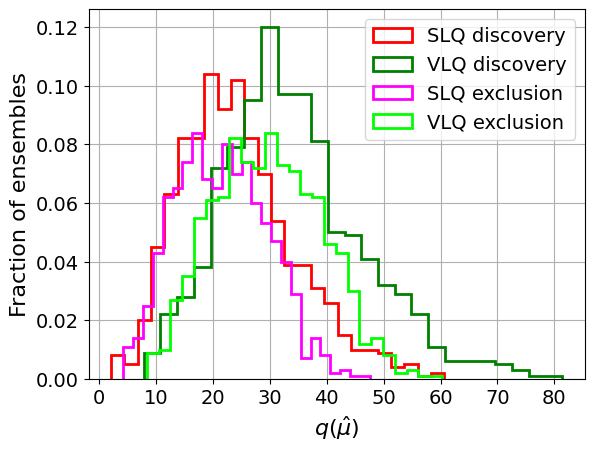


 Binned Likelihood:
Z_dis_SLQ =  4.808677896947962  +-  1.0450687400988194
Z_dis_VLQ =  5.688292449596747  +-  1.0768420530702436

Z_exc_SLQ =  4.601150054700785  +-  0.8614679327110631
Z_exc_VLQ =  5.429419162036221  +-  0.8632222664136777

------------------------------------------

B_expected:  45962
S_expected_SLQ:  41.15958518397708
S_expected_VLQ:  52.985278863514786
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.901843436211855
Z_asimov_dis_VLQ =  3.6074548317845605

Z_asimov_exc_SLQ =  2.80315532497893
Z_asimov_exc_VLQ =  3.4580527661704514


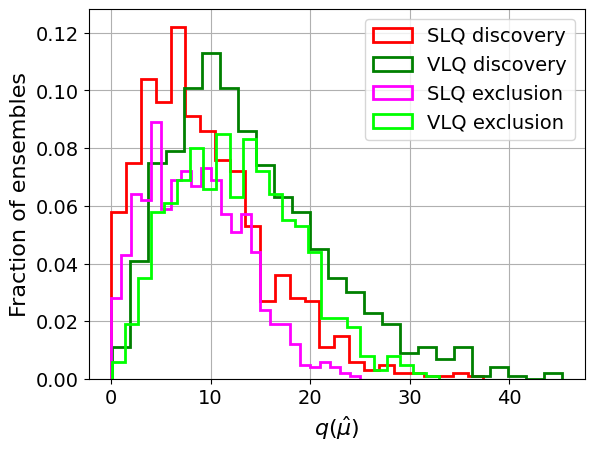


 Binned Likelihood:
Z_dis_SLQ =  2.885148231291476  +-  1.0763259273149517
Z_dis_VLQ =  3.514821672270475  +-  1.1027707761231638

Z_exc_SLQ =  2.8572193524303304  +-  0.8501648114154478
Z_exc_VLQ =  3.5158161127568266  +-  0.8664877827059158

------------------------------------------

B_expected:  45962
S_expected_SLQ:  23.839997871744895
S_expected_VLQ:  32.276568688385325
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.7166719610039611
Z_asimov_dis_VLQ =  2.248432305334476

Z_asimov_exc_SLQ =  1.6809123286727525
Z_asimov_exc_VLQ =  2.188088704546569


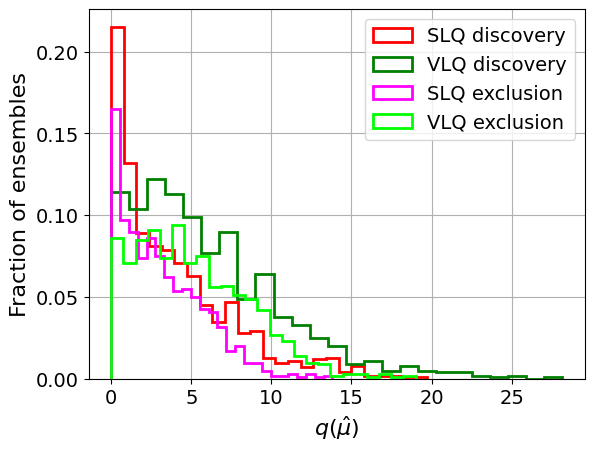


 Binned Likelihood:
Z_dis_SLQ =  1.7129386530769413  +-  1.0971349889373783
Z_dis_VLQ =  2.2214947996957863  +-  1.0517286793050025

Z_exc_SLQ =  1.6339853514630402  +-  0.7936413293689162
Z_exc_VLQ =  2.1345285527131304  +-  0.8208320028270981

------------------------------------------

B_expected:  45962
S_expected_SLQ:  14.070352992913703
S_expected_VLQ:  19.661628826745964
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.0291506381104085
Z_asimov_dis_VLQ =  1.3793474615310861

Z_asimov_exc_SLQ =  1.0160258586810924
Z_asimov_exc_VLQ =  1.3560442985366765


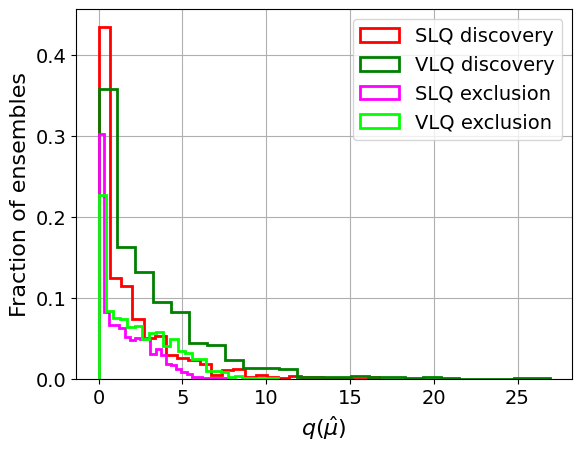


 Binned Likelihood:
Z_dis_SLQ =  0.9856860267530801  +-  1.2903184565220787
Z_dis_VLQ =  1.4205016325904614  +-  1.1983699287709513

Z_exc_SLQ =  1.0627525358400838  +-  0.7070854908869026
Z_exc_VLQ =  1.4140823679976142  +-  0.7410881587251206

------------------------------------------

m_asimov_dis_SLQ =  1594.9629092769776  GeV
m_asimov_dis_VLQ =  2035.4105142444896  GeV

m_asimov_exc_VLQ =  2265.2891929410603  GeV
m_asimov_exc_SLQ =  1805.4232870345115  GeV

m_BL_dis_SLQ =  1593.9399109998908  GeV
m_BL_dis_VLQ =  2031.6678952750153  GeV

m_BL_exc_VLQ =  2267.968286341195  GeV
m_BL_exc_SLQ =  1799.111512966461  GeV

######################################

beta:  0.5
B_expected:  45962
S_expected_SLQ:  2324.6608770680305
S_expected_VLQ:  2394.17647508564
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  75.23618416900874
Z_asimov_dis_VLQ =  86.57796201303982

Z_asimov_exc_SLQ =  52.47242065817048
Z_asimov_exc_VLQ =  57.79707892816452


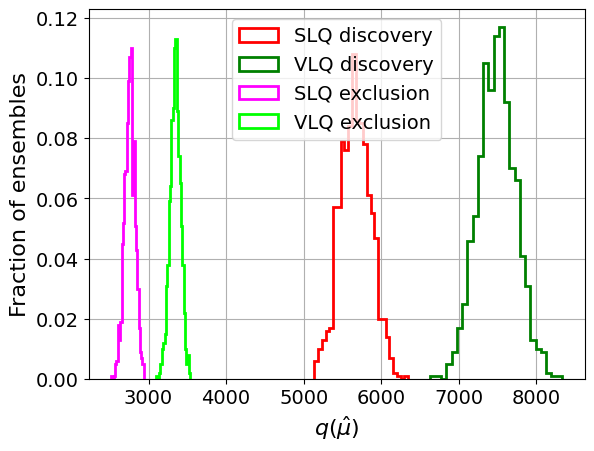


 Binned Likelihood:
Z_dis_SLQ =  75.233436086389  +-  1.3146942957948404
Z_dis_VLQ =  86.53608690187134  +-  1.4094954563125104

Z_exc_SLQ =  52.48816784452115  +-  0.6420469731434915
Z_exc_VLQ =  57.81979011499038  +-  0.5896829117545361

------------------------------------------

B_expected:  45962
S_expected_SLQ:  1313.6224978724342
S_expected_VLQ:  1380.2292156208025
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  52.15663009048006
Z_asimov_dis_VLQ =  58.42963080067996

Z_asimov_exc_SLQ =  38.282654310285636
Z_asimov_exc_VLQ =  41.74693014696082


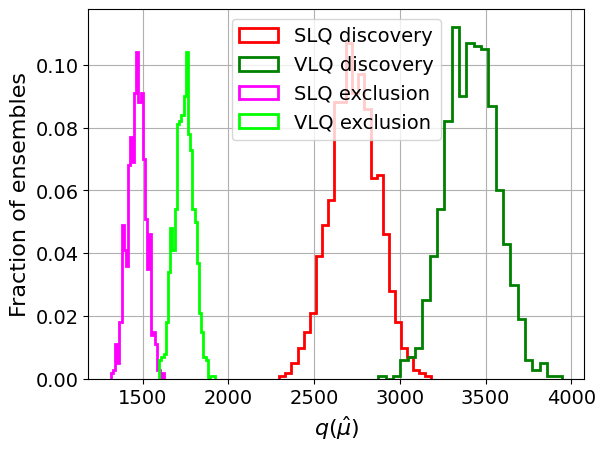


 Binned Likelihood:
Z_dis_SLQ =  52.243276342037916  +-  1.3342402357347187
Z_dis_VLQ =  58.44791602981262  +-  1.2886296735360698

Z_exc_SLQ =  38.2867742249051  +-  0.675340108626646
Z_exc_VLQ =  41.74602547989464  +-  0.6488957355700391

------------------------------------------

B_expected:  45962
S_expected_SLQ:  742.3035694965645
S_expected_VLQ:  795.6943472953774
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  34.81062696516058
Z_asimov_dis_VLQ =  38.614899524140895

Z_asimov_exc_SLQ =  27.135992557370315
Z_asimov_exc_VLQ =  29.537546151630163


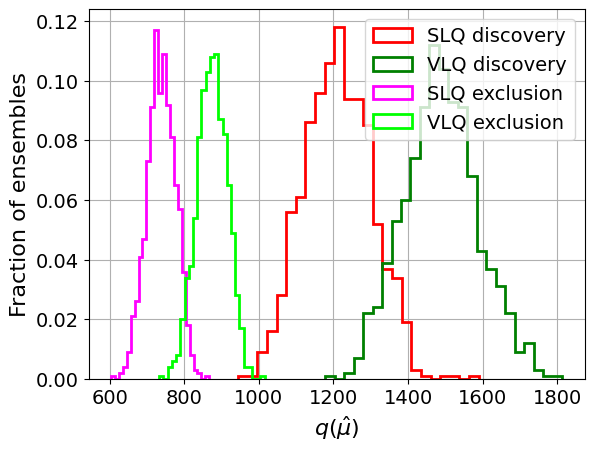


 Binned Likelihood:
Z_dis_SLQ =  34.78371234849335  +-  1.2842409676520898
Z_dis_VLQ =  38.54896020829904  +-  1.2844369292825724

Z_exc_SLQ =  27.16700509641057  +-  0.6993074875067143
Z_exc_VLQ =  29.575104070436822  +-  0.681851037293127

------------------------------------------

B_expected:  45962
S_expected_SLQ:  419.46190034029854
S_expected_VLQ:  466.1543813183168
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  22.478948849155525
Z_asimov_dis_VLQ =  25.247200137761386

Z_asimov_exc_SLQ =  18.609587998514314
Z_asimov_exc_VLQ =  20.562118562399508


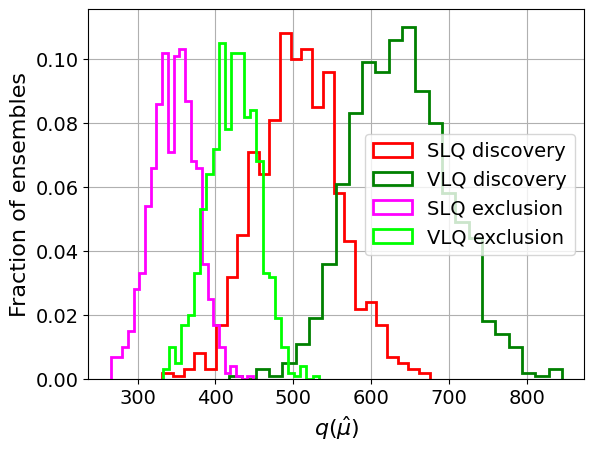


 Binned Likelihood:
Z_dis_SLQ =  22.464924453255698  +-  1.1778365565491364
Z_dis_VLQ =  25.233979469514473  +-  1.2285942874543097

Z_exc_SLQ =  18.64712597138535  +-  0.7715677595370012
Z_exc_VLQ =  20.599207760477494  +-  0.7588303210391959

------------------------------------------

B_expected:  45962
S_expected_SLQ:  237.03009532397087
S_expected_VLQ:  273.0946976824465
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.09319637124478
Z_asimov_dis_VLQ =  16.145111131529124

Z_asimov_exc_SLQ =  12.314902040395214
Z_asimov_exc_VLQ =  13.900030648675424


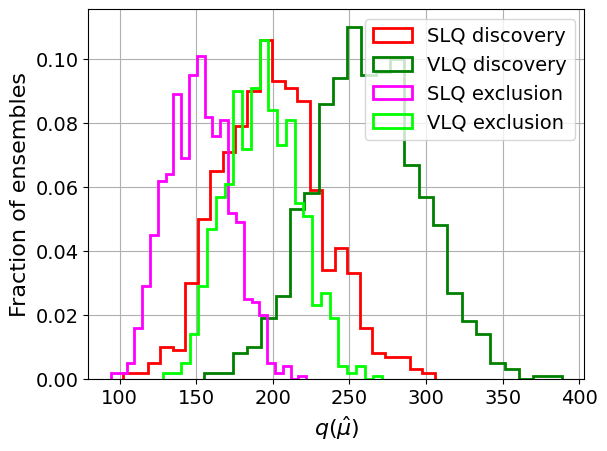


 Binned Likelihood:
Z_dis_SLQ =  14.083480054974762  +-  1.1646932730231647
Z_dis_VLQ =  16.15282588442882  +-  1.0826973238391484

Z_exc_SLQ =  12.297886454712142  +-  0.8390500003810795
Z_exc_VLQ =  13.880164044993446  +-  0.8278719322658584

------------------------------------------

B_expected:  45962
S_expected_SLQ:  137.45125294537868
S_expected_VLQ:  163.2289749902154
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.819964291890184
Z_asimov_dis_VLQ =  10.295296779133247

Z_asimov_exc_SLQ =  8.037928644290224
Z_asimov_exc_VLQ =  9.264828011886003


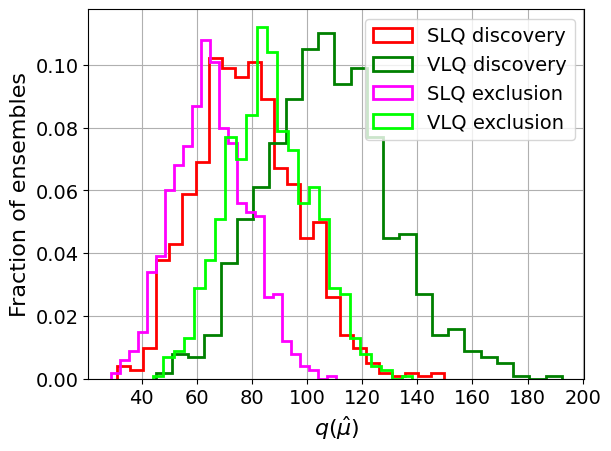


 Binned Likelihood:
Z_dis_SLQ =  8.80214663105697  +-  1.048680663641512
Z_dis_VLQ =  10.34340371999103  +-  1.0947945264512018

Z_exc_SLQ =  8.043637398597589  +-  0.8325835164475728
Z_exc_VLQ =  9.26957260407316  +-  0.8260682471118795

------------------------------------------

B_expected:  45962
S_expected_SLQ:  79.70653224617696
S_expected_VLQ:  97.56212223255078
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.399417630906506
Z_asimov_dis_VLQ =  6.417805402803258

Z_asimov_exc_SLQ =  5.080309160065684
Z_asimov_exc_VLQ =  5.978785828259657


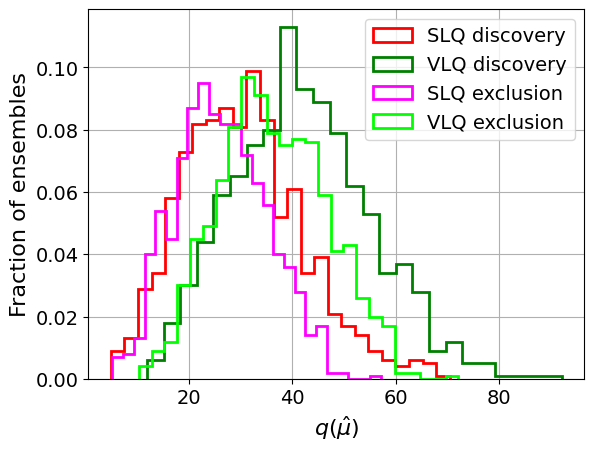


 Binned Likelihood:
Z_dis_SLQ =  5.447156662514263  +-  1.0694138766657244
Z_dis_VLQ =  6.402600585118755  +-  1.0339124740131396

Z_exc_SLQ =  5.069555693745073  +-  0.8654680697596299
Z_exc_VLQ =  5.971882638046793  +-  0.8652786541548343

------------------------------------------

B_expected:  45962
S_expected_SLQ:  46.16673250275495
S_expected_VLQ:  59.43104588984104
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.2417502387534873
Z_asimov_dis_VLQ =  4.026578662269442

Z_asimov_exc_SLQ =  3.119766164322435
Z_asimov_exc_VLQ =  3.8425777545465305


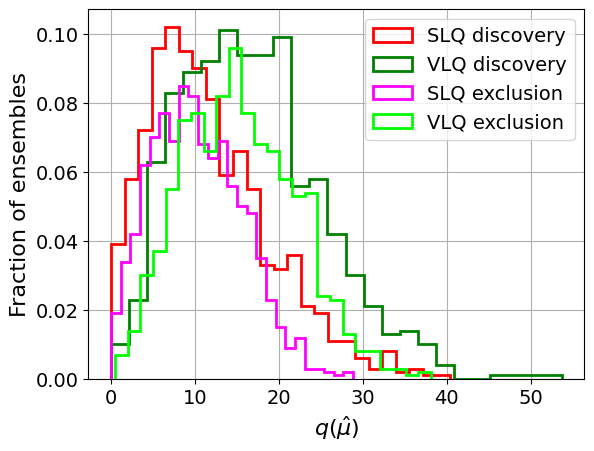


 Binned Likelihood:
Z_dis_SLQ =  3.231510729088947  +-  1.1304871993711747
Z_dis_VLQ =  3.975383352189352  +-  1.0434651483827881

Z_exc_SLQ =  3.1418893689717224  +-  0.8551944031503448
Z_exc_VLQ =  3.862817439693958  +-  0.8699780382108853

------------------------------------------

B_expected:  45962
S_expected_SLQ:  26.74018213962831
S_expected_VLQ:  36.203078968919264
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.9207094308537074
Z_asimov_dis_VLQ =  2.5138983997907087

Z_asimov_exc_SLQ =  1.8762143302746916
Z_asimov_exc_VLQ =  2.4390436334417407


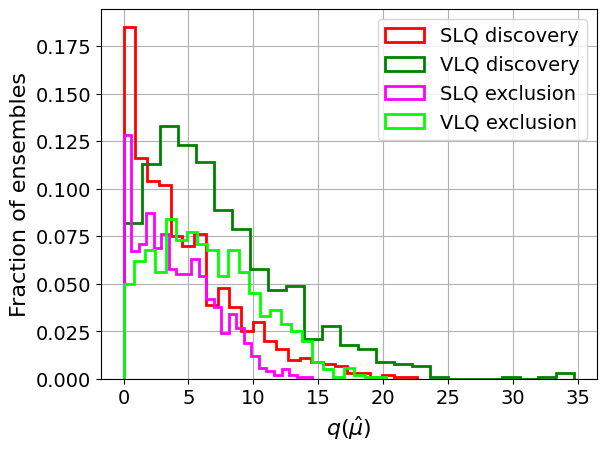


 Binned Likelihood:
Z_dis_SLQ =  1.8810879973360355  +-  1.1100699497235487
Z_dis_VLQ =  2.4726895320357745  +-  1.0847898267942329

Z_exc_SLQ =  1.8870595378244732  +-  0.7793979641647395
Z_exc_VLQ =  2.4418354108634857  +-  0.8102025744639498

------------------------------------------

B_expected:  45962
S_expected_SLQ:  15.782040074982554
S_expected_VLQ:  22.053505995152697
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.1525761786299413
Z_asimov_dis_VLQ =  1.5440107229091082

Z_asimov_exc_SLQ =  1.1361765098908851
Z_asimov_exc_VLQ =  1.5149561686939008


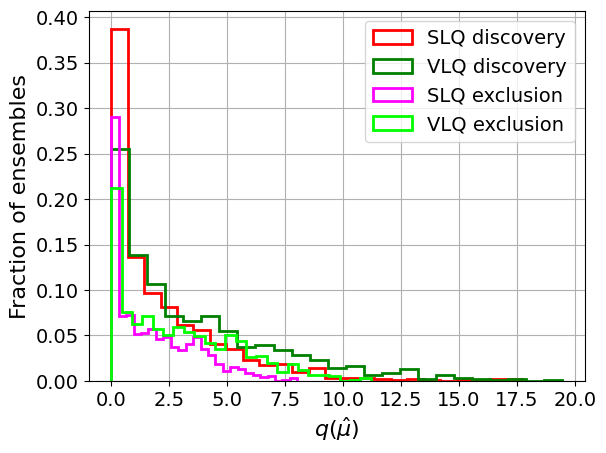


 Binned Likelihood:
Z_dis_SLQ =  1.1639269200045346  +-  1.167299632063509
Z_dis_VLQ =  1.5204728846686482  +-  1.1484215292255426

Z_exc_SLQ =  1.1737887038117862  +-  0.7543447504760339
Z_exc_VLQ =  1.5536050522183302  +-  0.7970561248905598

------------------------------------------

m_asimov_dis_SLQ =  1618.5115478112662  GeV
m_asimov_dis_VLQ =  2059.2919683763134  GeV

m_asimov_exc_VLQ =  2285.943164125377  GeV
m_asimov_exc_SLQ =  1831.263362081039  GeV

m_BL_dis_SLQ =  1620.1817743425715  GeV
m_BL_dis_VLQ =  2057.7863639928905  GeV

m_BL_exc_VLQ =  2289.7269245702964  GeV
m_BL_exc_SLQ =  1833.9570748337499  GeV

######################################

beta:  0.7
B_expected:  45962
S_expected_SLQ:  2359.4951996660225
S_expected_VLQ:  2430.0524673700907
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  76.07196894292798
Z_asimov_dis_VLQ =  87.51322417324634

Z_asimov_exc_SLQ =  52.95897030245368
Z_asimov_exc_VLQ =  58.309121619293855


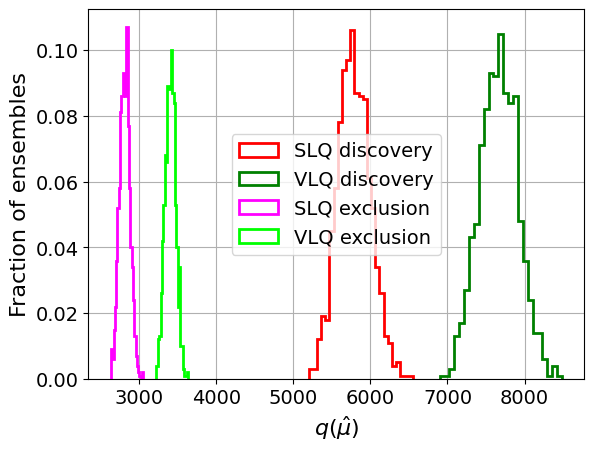


 Binned Likelihood:
Z_dis_SLQ =  75.98572946850128  +-  1.3898029002226677
Z_dis_VLQ =  87.55361978445092  +-  1.4190113183270485

Z_exc_SLQ =  52.991279974528325  +-  0.6376744586412684
Z_exc_VLQ =  58.343913744917565  +-  0.59303252045322

------------------------------------------

B_expected:  45962
S_expected_SLQ:  1333.3067237800783
S_expected_VLQ:  1400.9115225458233
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  52.756508062805835
Z_asimov_dis_VLQ =  59.0892431034751

Z_asimov_exc_SLQ =  38.65074875261531
Z_asimov_exc_VLQ =  42.13631632205089


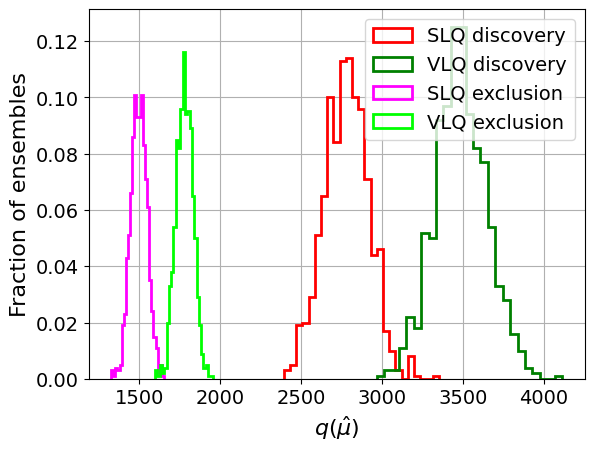


 Binned Likelihood:
Z_dis_SLQ =  52.715796794669615  +-  1.3022459989557704
Z_dis_VLQ =  58.986552455482595  +-  1.3634273953373577

Z_exc_SLQ =  38.665805769299894  +-  0.6570683807537259
Z_exc_VLQ =  42.154845805183804  +-  0.6281994597945771

------------------------------------------

B_expected:  45962
S_expected_SLQ:  753.4267583713639
S_expected_VLQ:  807.617580424351
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  35.22902861403643
Z_asimov_dis_VLQ =  39.07247231088578

Z_asimov_exc_SLQ =  27.412555754442334
Z_asimov_exc_VLQ =  29.831759124541296


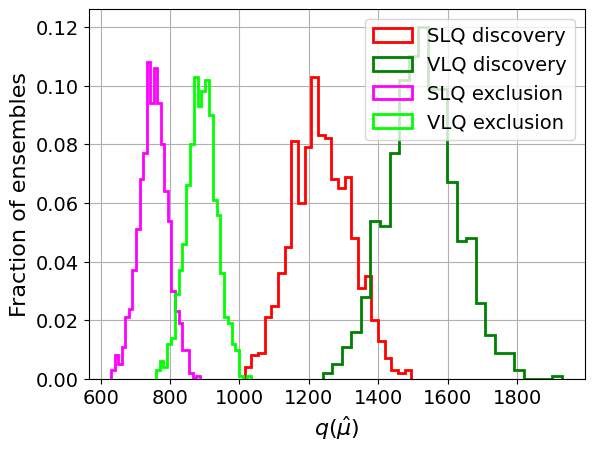


 Binned Likelihood:
Z_dis_SLQ =  35.113835775039966  +-  1.2078148744060502
Z_dis_VLQ =  39.06295180208771  +-  1.266602872439271

Z_exc_SLQ =  27.423235392088397  +-  0.744546805539386
Z_exc_VLQ =  29.847140896671267  +-  0.7247568475214419

------------------------------------------

B_expected:  45962
S_expected_SLQ:  425.7474068837088
S_expected_VLQ:  473.1395602145135
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  22.762276260731404
Z_asimov_dis_VLQ =  25.56122224709703

Z_asimov_exc_SLQ =  18.813406079751342
Z_asimov_exc_VLQ =  20.78247633765393


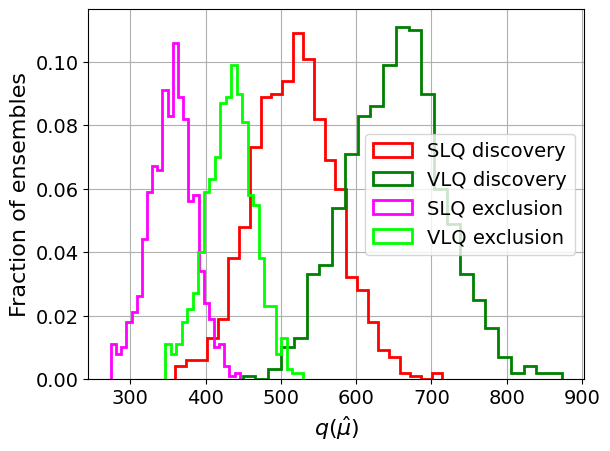


 Binned Likelihood:
Z_dis_SLQ =  22.753737071162234  +-  1.1993226457862185
Z_dis_VLQ =  25.581324462932898  +-  1.2541141282731596

Z_exc_SLQ =  18.864684720880174  +-  0.7889769947920464
Z_exc_VLQ =  20.83108319159379  +-  0.7738746032928631

------------------------------------------

B_expected:  45962
S_expected_SLQ:  240.581917823071
S_expected_VLQ:  277.18693706786166
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.279138454102956
Z_asimov_dis_VLQ =  16.355404374708055

Z_asimov_exc_SLQ =  12.460423090905419
Z_asimov_exc_VLQ =  14.060687713792657


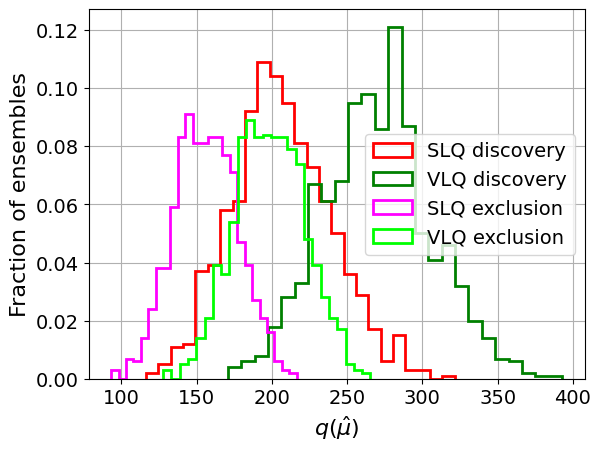


 Binned Likelihood:
Z_dis_SLQ =  14.315308511024325  +-  1.1487213310724627
Z_dis_VLQ =  16.404969931233666  +-  1.099411061078497

Z_exc_SLQ =  12.465084540090597  +-  0.839876428480446
Z_exc_VLQ =  14.066573901071884  +-  0.8277179698522412

------------------------------------------

B_expected:  45962
S_expected_SLQ:  139.51091736087676
S_expected_VLQ:  165.67491057946148
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.940795072401295
Z_asimov_dis_VLQ =  10.434728614366993

Z_asimov_exc_SLQ =  8.139441114463303
Z_asimov_exc_VLQ =  9.37944064532843


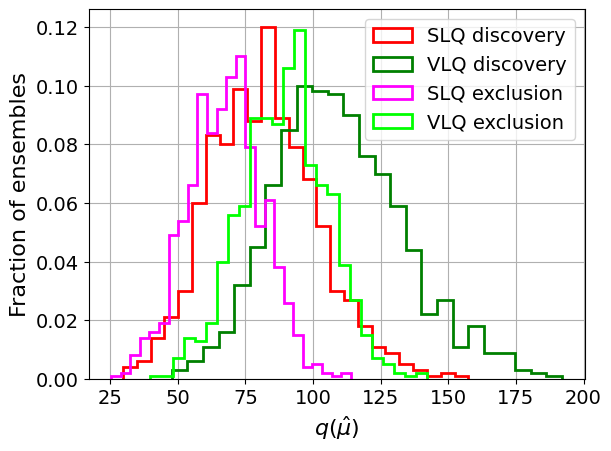


 Binned Likelihood:
Z_dis_SLQ =  9.018107949085056  +-  1.1071129137988793
Z_dis_VLQ =  10.387985131040312  +-  1.1473096183670224

Z_exc_SLQ =  8.233907759122111  +-  0.8369778922720029
Z_exc_VLQ =  9.474405701300364  +-  0.8318897942193235

------------------------------------------

B_expected:  45962
S_expected_SLQ:  80.90090992286092
S_expected_VLQ:  99.02406038994765
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.4756258184451685
Z_asimov_dis_VLQ =  6.507540415795217

Z_asimov_exc_SLQ =  5.148094693878645
Z_asimov_exc_VLQ =  6.057173520699012


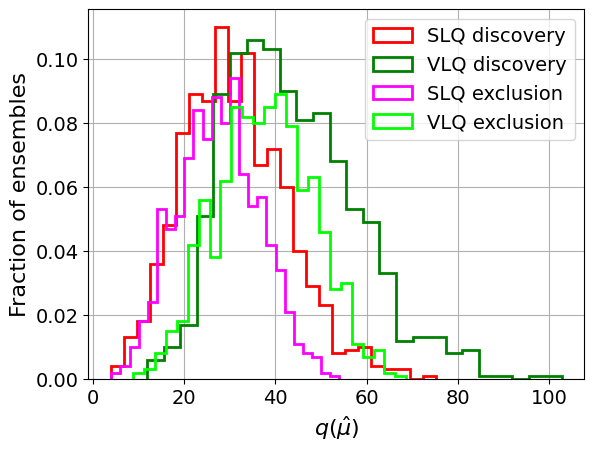


 Binned Likelihood:
Z_dis_SLQ =  5.503379430506985  +-  1.0342659840274016
Z_dis_VLQ =  6.46747647157258  +-  1.0885191759972503

Z_exc_SLQ =  5.237176575831343  +-  0.8436033132440004
Z_exc_VLQ =  6.1447519400996455  +-  0.8466199434100931

------------------------------------------

B_expected:  45962
S_expected_SLQ:  46.858526677621654
S_expected_VLQ:  60.32160168887608
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.288508911288839
Z_asimov_dis_VLQ =  4.0841855036648775

Z_asimov_exc_SLQ =  3.163145090361962
Z_asimov_exc_VLQ =  3.8951792164601775


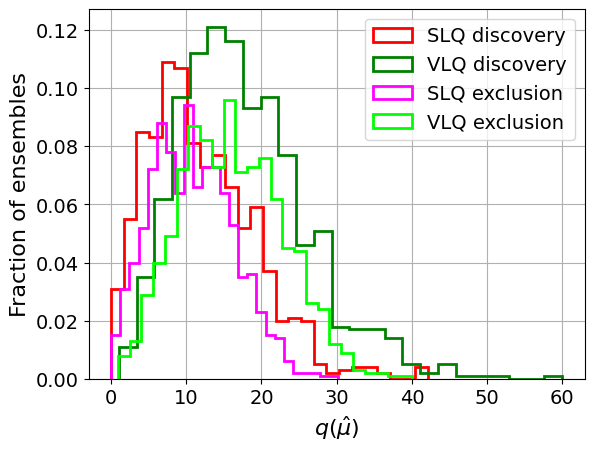


 Binned Likelihood:
Z_dis_SLQ =  3.3003026390635157  +-  1.074061050703616
Z_dis_VLQ =  4.058819441264776  +-  1.0356751975880985

Z_exc_SLQ =  3.241174209219472  +-  0.8335457530641314
Z_exc_VLQ =  3.9686358999248066  +-  0.8489586927523246

------------------------------------------

B_expected:  45962
S_expected_SLQ:  27.140875479534174
S_expected_VLQ:  36.745570884314034
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.9488223296062719
Z_asimov_dis_VLQ =  2.5504480524248625

Z_asimov_exc_SLQ =  1.903053193211967
Z_asimov_exc_VLQ =  2.4734820758778193


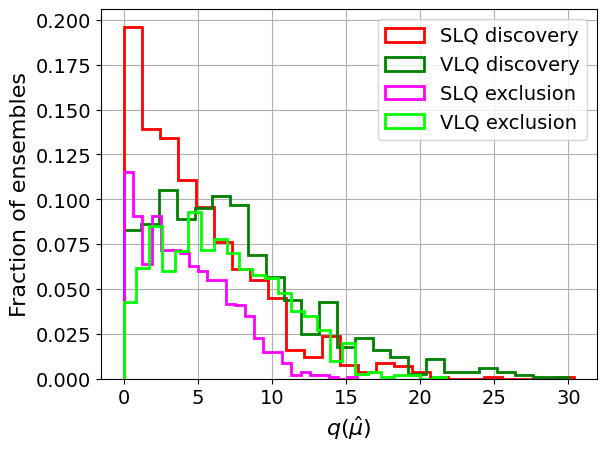


 Binned Likelihood:
Z_dis_SLQ =  1.9839325741539124  +-  1.088374868836528
Z_dis_VLQ =  2.532762385933187  +-  1.064803591608159

Z_exc_SLQ =  1.9263181684681043  +-  0.7730617538834004
Z_exc_VLQ =  2.495801532763465  +-  0.8002234361310285

------------------------------------------

B_expected:  45962
S_expected_SLQ:  16.018529053073742
S_expected_VLQ:  22.383970945903197
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.1695996527879249
Z_asimov_dis_VLQ =  1.5667098055751922

Z_asimov_exc_SLQ =  1.152720721347057
Z_asimov_exc_VLQ =  1.536815055818185


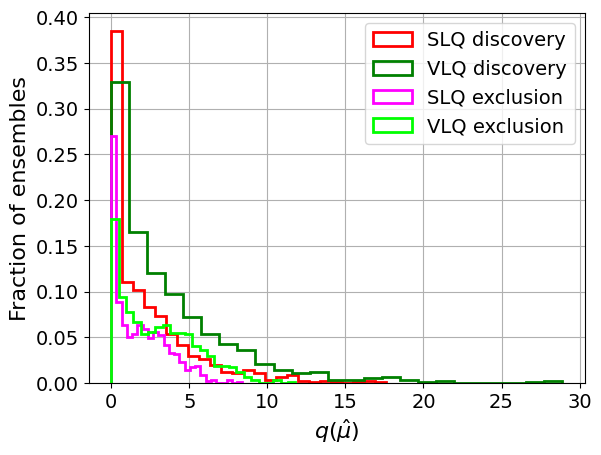


 Binned Likelihood:
Z_dis_SLQ =  1.1941222227740844  +-  1.2011992988070734
Z_dis_VLQ =  1.5341546820883367  +-  1.307771265966641

Z_exc_SLQ =  1.2427128539577577  +-  0.6799442432398001
Z_exc_VLQ =  1.623575359049726  +-  0.7274762542148996

------------------------------------------

m_asimov_dis_SLQ =  1621.746703017516  GeV
m_asimov_dis_VLQ =  2062.208816721359  GeV

m_asimov_exc_VLQ =  2288.465637326869  GeV
m_asimov_exc_SLQ =  1834.4113544251595  GeV

m_BL_dis_SLQ =  1622.8489280292933  GeV
m_BL_dis_VLQ =  2060.9250903348848  GeV

m_BL_exc_VLQ =  2297.560464413588  GeV
m_BL_exc_SLQ =  1841.1735449596729  GeV

######################################

beta:  0.9
B_expected:  45962
S_expected_SLQ:  2023.0112776436777
S_expected_VLQ:  2083.5064836967595
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  67.8130498419261
Z_asimov_dis_VLQ =  78.25847286619259

Z_asimov_exc_SLQ =  48.1064960446359
Z_asimov_exc_VLQ =  53.193524842975854


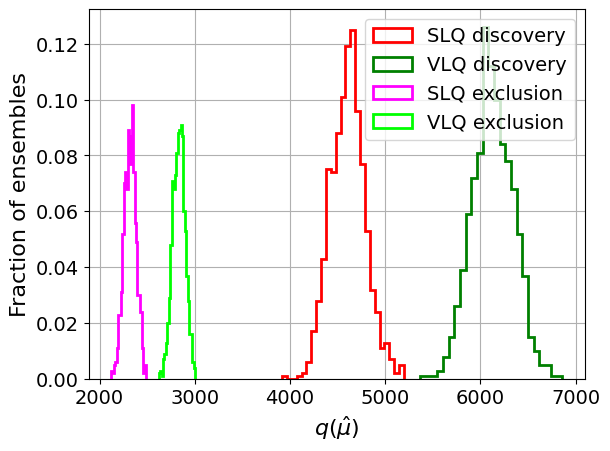


 Binned Likelihood:
Z_dis_SLQ =  67.89453128705722  +-  1.3342623454292737
Z_dis_VLQ =  78.22220088309189  +-  1.375338081566987

Z_exc_SLQ =  48.113342625601696  +-  0.6585018769582731
Z_exc_VLQ =  53.21213194357955  +-  0.6123676587493759

------------------------------------------

B_expected:  45962
S_expected_SLQ:  1143.1659361489835
S_expected_VLQ:  1201.1297202436883
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  46.83634641406401
Z_asimov_dis_VLQ =  52.573072469325

Z_asimov_exc_SLQ =  34.97994591789008
Z_asimov_exc_VLQ =  38.24815594763801


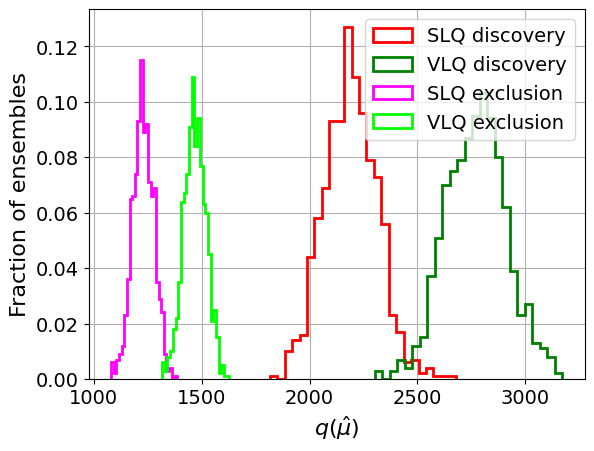


 Binned Likelihood:
Z_dis_SLQ =  46.760010650273266  +-  1.3020161959410963
Z_dis_VLQ =  52.681455659675784  +-  1.3246576676149533

Z_exc_SLQ =  35.01637548987422  +-  0.6948129191306648
Z_exc_VLQ =  38.285626020649175  +-  0.6688278994657614

------------------------------------------

B_expected:  45962
S_expected_SLQ:  645.9817461292274
S_expected_VLQ:  692.4444997612296
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  31.108613152891184
Z_asimov_dis_VLQ =  34.56252697400871

Z_asimov_exc_SLQ =  24.65824233608635
Z_asimov_exc_VLQ =  26.898584835121273


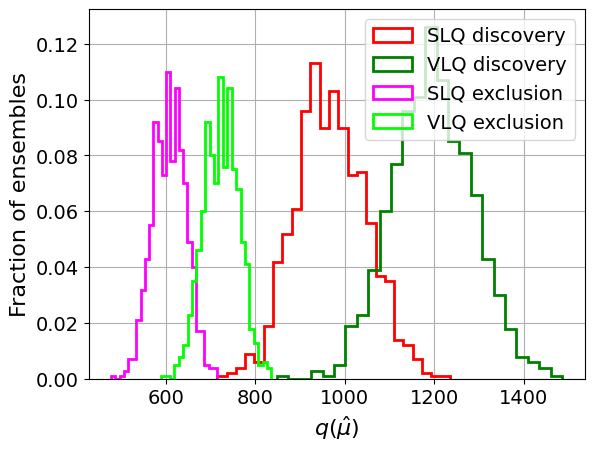


 Binned Likelihood:
Z_dis_SLQ =  31.066433521002768  +-  1.2755165071834793
Z_dis_VLQ =  34.56927530186977  +-  1.2938302274874187

Z_exc_SLQ =  24.653111431879612  +-  0.748127636445242
Z_exc_VLQ =  26.89271446142768  +-  0.7302585491269333

------------------------------------------

B_expected:  45962
S_expected_SLQ:  365.0322347234301
S_expected_VLQ:  405.6658671519289
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  19.980054201480684
Z_asimov_dis_VLQ =  22.47483075618732

Z_asimov_exc_SLQ =  16.78955973633372
Z_asimov_exc_VLQ =  18.5918789743283


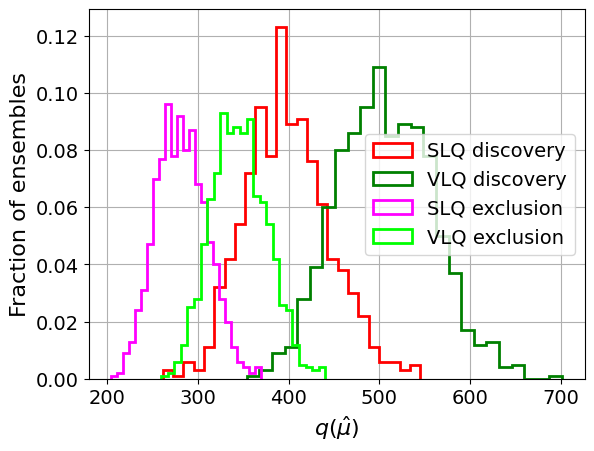


 Binned Likelihood:
Z_dis_SLQ =  19.898531937042982  +-  1.1517598328637237
Z_dis_VLQ =  22.466167819522255  +-  1.167479830211478

Z_exc_SLQ =  16.768171806924904  +-  0.831321727051931
Z_exc_VLQ =  18.567760946070074  +-  0.817013403114472

------------------------------------------

B_expected:  45962
S_expected_SLQ:  206.27290660396662
S_expected_VLQ:  237.65774127583083
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  12.459353155370406
Z_asimov_dis_VLQ =  14.295204119777852

Z_asimov_exc_SLQ =  11.02192543776216
Z_asimov_exc_VLQ =  12.47021817354851


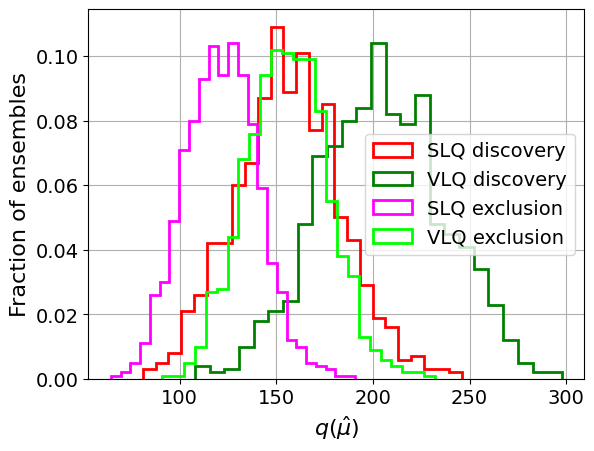


 Binned Likelihood:
Z_dis_SLQ =  12.464871315156518  +-  1.0961760542378745
Z_dis_VLQ =  14.248981950275995  +-  1.1281212433946515

Z_exc_SLQ =  11.024722372625941  +-  0.8553582915549683
Z_exc_VLQ =  12.468856199081143  +-  0.8455554353464987

------------------------------------------

B_expected:  45962
S_expected_SLQ:  119.61548352182183
S_expected_VLQ:  142.0482705674923
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  7.762089684590725
Z_asimov_dis_VLQ =  9.073147325068724

Z_asimov_exc_SLQ =  7.141030717544691
Z_asimov_exc_VLQ =  8.25028104315297


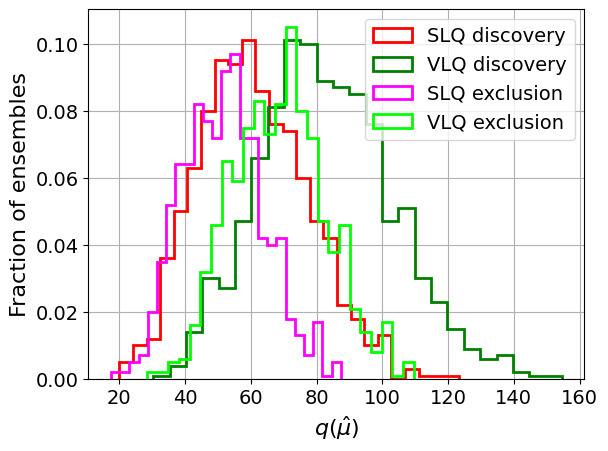


 Binned Likelihood:
Z_dis_SLQ =  7.71119311425406  +-  1.0803272828993364
Z_dis_VLQ =  9.043125295597253  +-  1.1100708983350636

Z_exc_SLQ =  7.189327507970812  +-  0.8504319995526176
Z_exc_VLQ =  8.298468403798033  +-  0.8461956406100333

------------------------------------------

B_expected:  45962
S_expected_SLQ:  69.36375762440579
S_expected_VLQ:  84.90239393379065
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  4.734386268264461
Z_asimov_dis_VLQ =  5.633896798171877

Z_asimov_exc_SLQ =  4.484714927144619
Z_asimov_exc_VLQ =  5.288754468386507


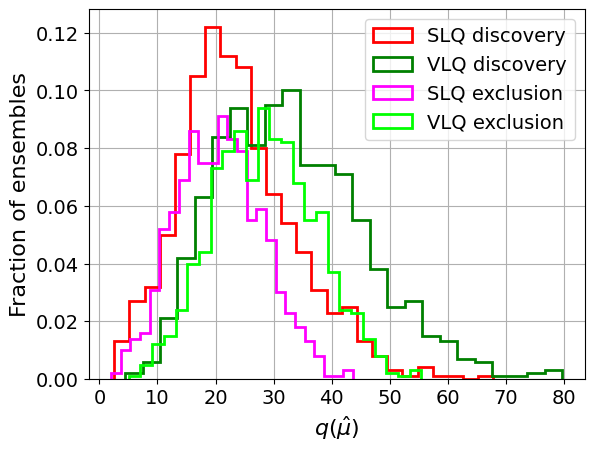


 Binned Likelihood:
Z_dis_SLQ =  4.750866259754664  +-  1.049821373834633
Z_dis_VLQ =  5.635786125479147  +-  1.1044024122213854

Z_exc_SLQ =  4.528230712217077  +-  0.8120744474434965
Z_exc_VLQ =  5.334244240797899  +-  0.8161408026377069

------------------------------------------

B_expected:  45962
S_expected_SLQ:  40.176105438152035
S_expected_VLQ:  51.719232367753605
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.8347728893628417
Z_asimov_dis_VLQ =  3.524677590671071

Z_asimov_exc_SLQ =  2.7404139194719015
Z_asimov_exc_VLQ =  3.38172511757023


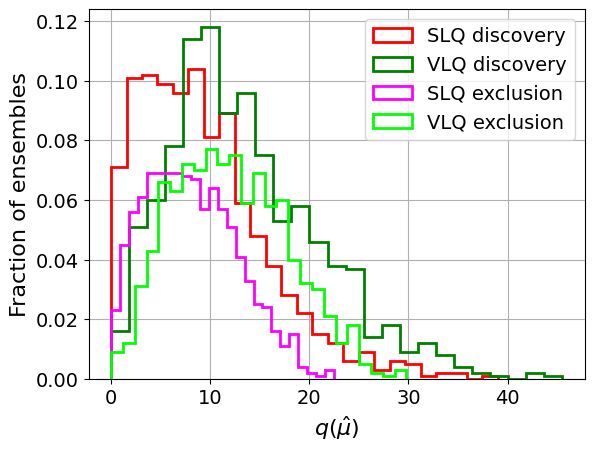


 Binned Likelihood:
Z_dis_SLQ =  2.8814237189247556  +-  1.1174997849270472
Z_dis_VLQ =  3.510372355664945  +-  1.082343779855207

Z_exc_SLQ =  2.781887477835307  +-  0.8202590474677869
Z_exc_VLQ =  3.4238212026994916  +-  0.8378710710953643

------------------------------------------

B_expected:  45962
S_expected_SLQ:  23.270357654464462
S_expected_VLQ:  31.505342461787812
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.6764796217503777
Z_asimov_dis_VLQ =  2.196098252362908

Z_asimov_exc_SLQ =  1.642333962450585
Z_asimov_exc_VLQ =  2.138442960821112


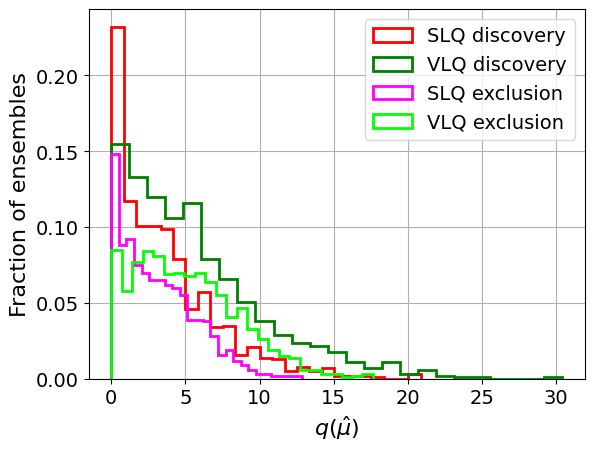


 Binned Likelihood:
Z_dis_SLQ =  1.6889519132373214  +-  1.0361049509904632
Z_dis_VLQ =  2.173911097849242  +-  1.0915170672872891

Z_exc_SLQ =  1.6609176935523833  +-  0.7662621612543163
Z_exc_VLQ =  2.1487953447315835  +-  0.8005053852478554

------------------------------------------

B_expected:  45962
S_expected_SLQ:  13.734151665245166
S_expected_VLQ:  19.191827840302544
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.0048641871680621
Z_asimov_dis_VLQ =  1.346928359580896

Z_asimov_exc_SLQ =  0.9923422299079278
Z_asimov_exc_VLQ =  1.324685927160961


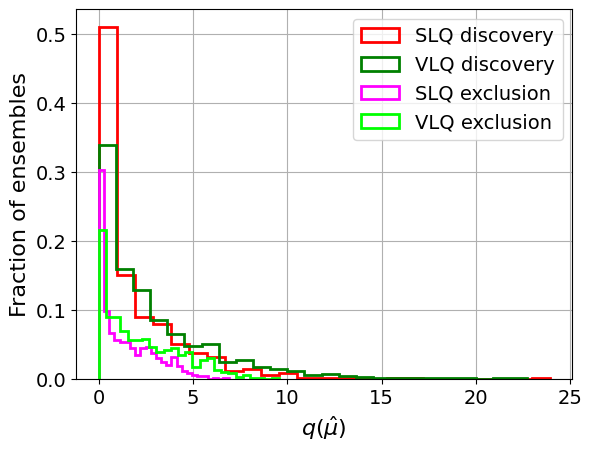


 Binned Likelihood:
Z_dis_SLQ =  0.9606392905414167  +-  1.3030878147318359
Z_dis_VLQ =  1.3542178315735334  +-  1.1917613435804737

Z_exc_SLQ =  0.9960777960214736  +-  0.7157990551567451
Z_exc_VLQ =  1.3341460395456055  +-  0.7455664226046327

------------------------------------------

m_asimov_dis_SLQ =  1591.2272209258253  GeV
m_asimov_dis_VLQ =  2030.0536234412057  GeV

m_asimov_exc_VLQ =  2260.6556150611136  GeV
m_asimov_exc_SLQ =  1799.7705390682365  GeV

m_BL_dis_SLQ =  1591.5842488856704  GeV
m_BL_dis_VLQ =  2029.9135224636625  GeV

m_BL_exc_VLQ =  2261.85995796867  GeV
m_BL_exc_SLQ =  1802.416230834005  GeV

######################################

beta:  1.0
B_expected:  45962
S_expected_SLQ:  837.7431545229355
S_expected_VLQ:  862.7946435148572
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  34.074552316452454
Z_asimov_dis_VLQ =  40.06021828304839

Z_asimov_exc_SLQ =  26.879947795898044
Z_asimov_exc_VLQ =  30.50643508205198


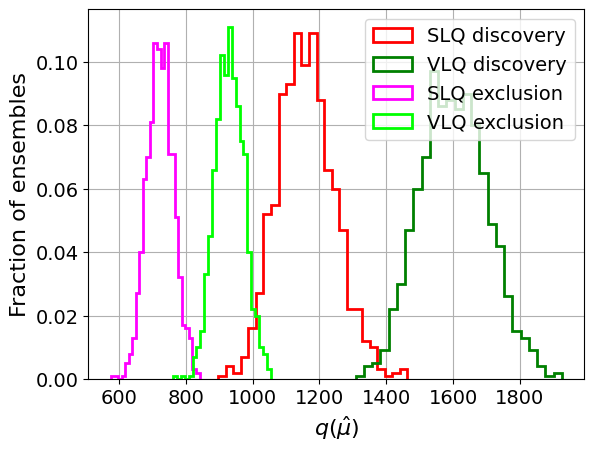


 Binned Likelihood:
Z_dis_SLQ =  33.96955325198674  +-  1.2581863140408163
Z_dis_VLQ =  39.999820543964226  +-  1.265489181735158

Z_exc_SLQ =  26.875667552443467  +-  0.7390965249558471
Z_exc_VLQ =  30.500766103072866  +-  0.7077692307731702

------------------------------------------

B_expected:  45962
S_expected_SLQ:  473.39302952778434
S_expected_VLQ:  497.3962389375429
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  22.91825249569378
Z_asimov_dis_VLQ =  26.051936028950905

Z_asimov_exc_SLQ =  18.987291886139573
Z_asimov_exc_VLQ =  21.137576441901583


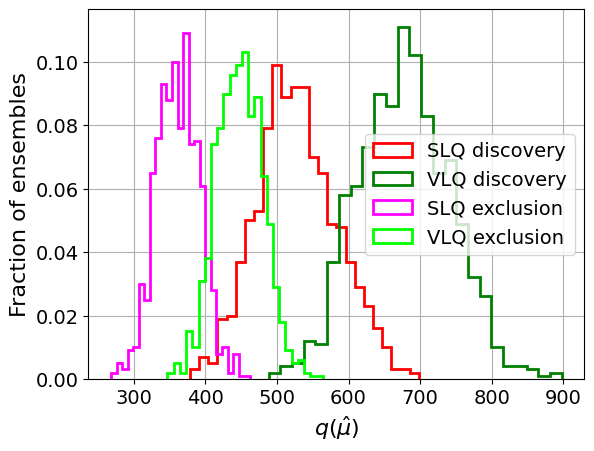


 Binned Likelihood:
Z_dis_SLQ =  22.891621324733727  +-  1.212662380302575
Z_dis_VLQ =  26.00431761392141  +-  1.2273484429178831

Z_exc_SLQ =  18.99226103048235  +-  0.7937659814833316
Z_exc_VLQ =  21.141734541314175  +-  0.7743535034099347

------------------------------------------

B_expected:  45962
S_expected_SLQ:  267.5055704073298
S_expected_VLQ:  286.7461224623991
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.742993248530912
Z_asimov_dis_VLQ =  16.539159713960082

Z_asimov_exc_SLQ =  12.83761913209542
Z_asimov_exc_VLQ =  14.20485161512122


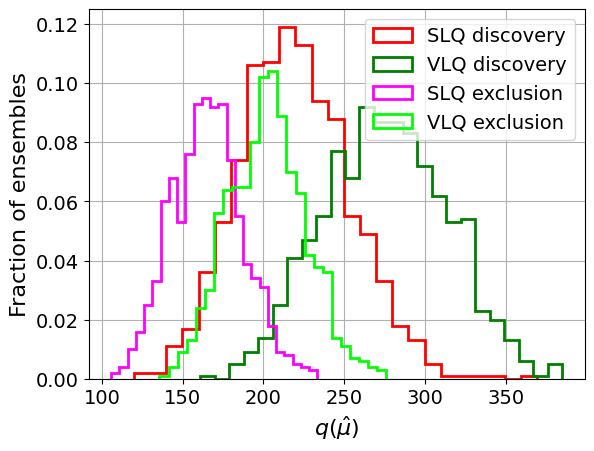


 Binned Likelihood:
Z_dis_SLQ =  14.746077452045169  +-  1.1514565864007111
Z_dis_VLQ =  16.587757969513905  +-  1.1503871140374116

Z_exc_SLQ =  12.860371899018931  +-  0.8495966851170806
Z_exc_VLQ =  14.228072789399167  +-  0.8374640043678986

------------------------------------------

B_expected:  45962
S_expected_SLQ:  151.1624078418141
S_expected_VLQ:  167.9890799353207
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  9.163233143751894
Z_asimov_dis_VLQ =  10.398979199440504

Z_asimov_exc_SLQ =  8.329355381849629
Z_asimov_exc_VLQ =  9.351313538340188


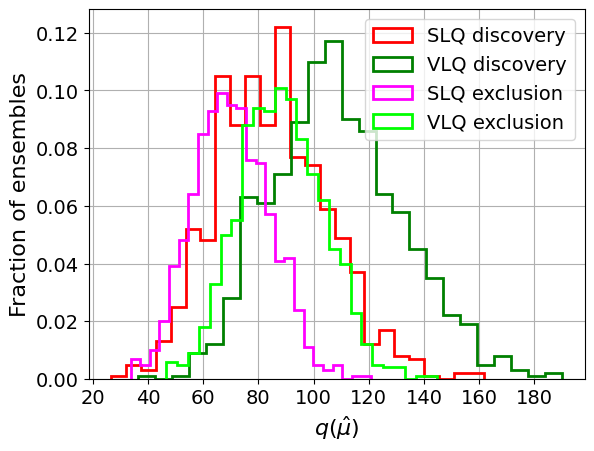


 Binned Likelihood:
Z_dis_SLQ =  9.177710496504861  +-  1.104504968580631
Z_dis_VLQ =  10.36681646045298  +-  1.132822387215544

Z_exc_SLQ =  8.33804567989277  +-  0.8234837170161319
Z_exc_VLQ =  9.35414233020719  +-  0.8175506100781734

------------------------------------------

B_expected:  45962
S_expected_SLQ:  85.41905691810908
S_expected_VLQ:  98.41573701215812
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.54641237858994
Z_asimov_dis_VLQ =  6.4157615387810845

Z_asimov_exc_SLQ =  5.2117960135566985
Z_asimov_exc_VLQ =  5.977263803911893


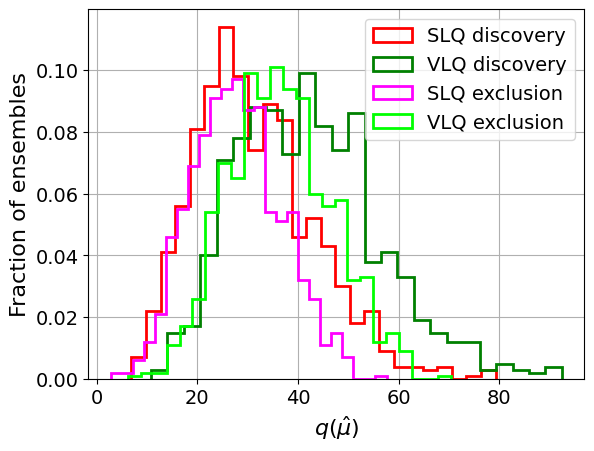


 Binned Likelihood:
Z_dis_SLQ =  5.44614301033053  +-  1.0938786157409373
Z_dis_VLQ =  6.421697259172747  +-  1.0930532595974667

Z_exc_SLQ =  5.228828610644306  +-  0.8442653194753764
Z_exc_VLQ =  5.992026329026738  +-  0.8448653977143713

------------------------------------------

B_expected:  45962
S_expected_SLQ:  49.53361041668259
S_expected_VLQ:  58.82318482096888
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.376556717058381
Z_asimov_dis_VLQ =  3.9741728958460176

Z_asimov_exc_SLQ =  3.2448868183920268
Z_asimov_exc_VLQ =  3.7947321679942076


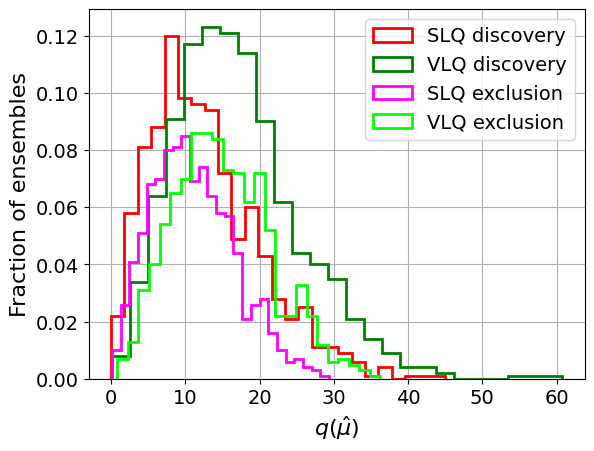


 Binned Likelihood:
Z_dis_SLQ =  3.372976409493714  +-  1.0941630081959772
Z_dis_VLQ =  3.978626592862948  +-  1.0555586936740324

Z_exc_SLQ =  3.2389227785526247  +-  0.8557289449572115
Z_exc_VLQ =  3.790130151832877  +-  0.8630317622909881

------------------------------------------

B_expected:  45962
S_expected_SLQ:  28.724018379925727
S_expected_VLQ:  35.158676625613225
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.024189997024069
Z_asimov_dis_VLQ =  2.421703485129201

Z_asimov_exc_SLQ =  1.9749552792892886
Z_asimov_exc_VLQ =  2.3520805482753557


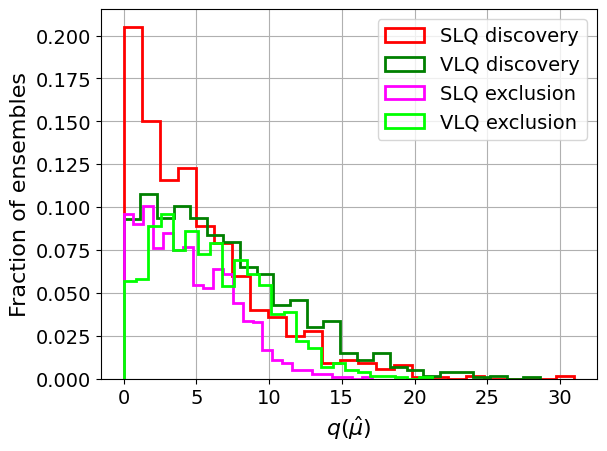


 Binned Likelihood:
Z_dis_SLQ =  2.0117814730431216  +-  1.116342637178048
Z_dis_VLQ =  2.4191566850262913  +-  1.0259437983937059

Z_exc_SLQ =  1.9624553218930714  +-  0.7881867722730796
Z_exc_VLQ =  2.3417993619204474  +-  0.8042634015713538

------------------------------------------

B_expected:  45962
S_expected_SLQ:  16.637206958829303
S_expected_VLQ:  21.41729675562297
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.1975273005571265
Z_asimov_dis_VLQ =  1.4956329273979738

Z_asimov_exc_SLQ =  1.1798562048547714
Z_asimov_exc_VLQ =  1.4683381212465116


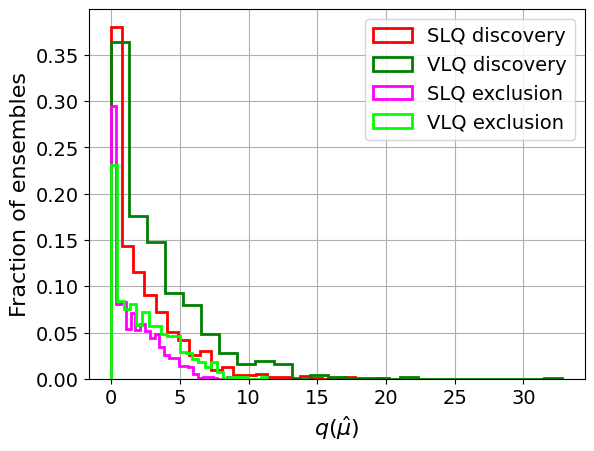


 Binned Likelihood:
Z_dis_SLQ =  1.2093544770175269  +-  1.1127489377995217
Z_dis_VLQ =  1.5046434896109886  +-  1.1374119293527556

Z_exc_SLQ =  1.1309906627051443  +-  0.7472208589786714
Z_exc_VLQ =  1.4268408929606593  +-  0.7669492072243468

------------------------------------------

B_expected:  45962
S_expected_SLQ:  9.63641826605856
S_expected_VLQ:  13.046583214803164
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7026892215862315
Z_asimov_dis_VLQ =  0.923762535276532

Z_asimov_exc_SLQ =  0.6965098804022553
Z_asimov_exc_VLQ =  0.9131642224020199


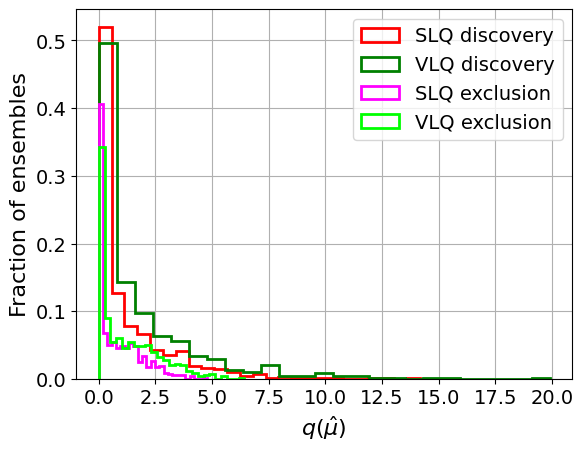


 Binned Likelihood:
Z_dis_SLQ =  0.7210243270223762  +-  1.3568075955942582
Z_dis_VLQ =  0.9026369197746313  +-  1.4026399972232726

Z_exc_SLQ =  0.6884240491565174  +-  0.6926027893310163
Z_exc_VLQ =  0.9049074482411795  +-  0.7181283458725125

------------------------------------------

B_expected:  45962
S_expected_SLQ:  5.687408502309627
S_expected_VLQ:  7.947470473186365
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4191959393622939
Z_asimov_dis_VLQ =  0.5632550522337874

Z_asimov_exc_SLQ =  0.4169767709929895
Z_asimov_exc_VLQ =  0.5592705723982921


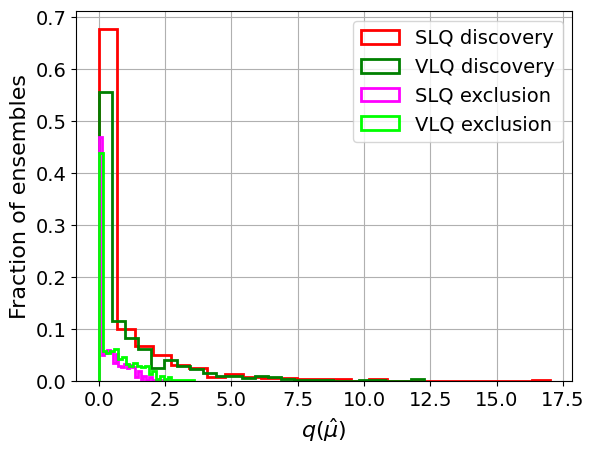


 Binned Likelihood:
Z_dis_SLQ =  0.38597132487370206  +-  2.1925317642506625
Z_dis_VLQ =  0.5536040127098366  +-  1.5183401550582947

Z_exc_SLQ =  0.4244489568889417  +-  0.6055941998619552
Z_exc_VLQ =  0.5492015384660681  +-  0.6493765931817694

------------------------------------------

m_asimov_dis_SLQ =  1425.1819689335587  GeV
m_asimov_dis_VLQ =  1857.9852606571424  GeV

m_asimov_exc_VLQ =  2080.026362851175  GeV
m_asimov_exc_SLQ =  1641.5170464853813  GeV

m_BL_dis_SLQ =  1421.5198822009986  GeV
m_BL_dis_VLQ =  1858.193046921569  GeV

m_BL_exc_VLQ =  2076.172390180871  GeV
m_BL_exc_SLQ =  1638.197858613954  GeV

######################################



In [ ]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_13TeV = []
m_asimov_exc_SLQ_13TeV = []

m_asimov_dis_VLQ_13TeV = []
m_asimov_exc_VLQ_13TeV = []


m_BL_dis_SLQ_13TeV = []
m_BL_exc_SLQ_13TeV = []

m_BL_dis_VLQ_13TeV = []
m_BL_exc_VLQ_13TeV = []


m_BL_dis_SLQ_low_13TeV = []
m_BL_exc_SLQ_low_13TeV = []

m_BL_dis_VLQ_low_13TeV = []
m_BL_exc_VLQ_low_13TeV = []


m_BL_dis_SLQ_high_13TeV = []
m_BL_exc_SLQ_high_13TeV = []

m_BL_dis_VLQ_high_13TeV = []
m_BL_exc_VLQ_high_13TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_13TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_13TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1800)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1800)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_13TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_13TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_13TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_13TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_13TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_13TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_13TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_13TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_13TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_13TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_13TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_13TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_13TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_13TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_13TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_13TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


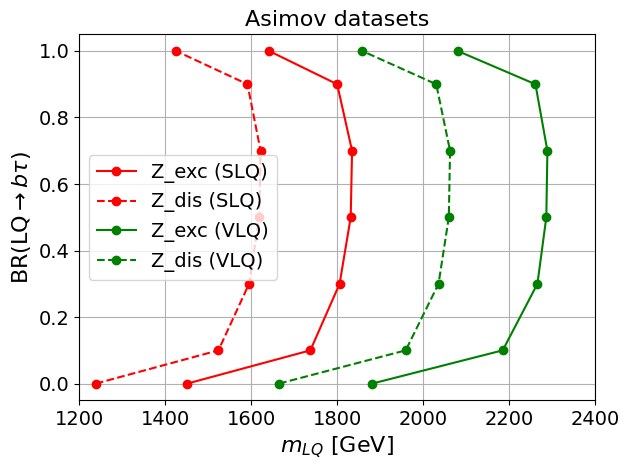

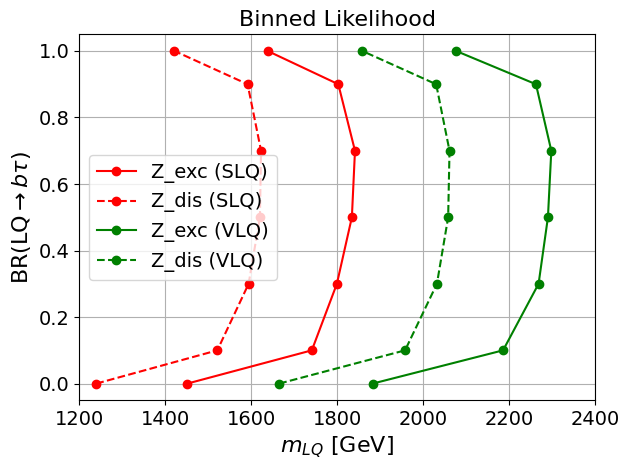

In [ ]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

# SAVE

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_13TeV,
    m_asimov_dis_SLQ_13TeV,
    m_asimov_exc_VLQ_13TeV,
    m_asimov_dis_VLQ_13TeV,
    m_BL_exc_SLQ_13TeV,
    m_BL_dis_SLQ_13TeV,
    m_BL_exc_VLQ_13TeV,
    m_BL_dis_VLQ_13TeV,
    m_BL_exc_SLQ_low_13TeV,
    m_BL_dis_SLQ_low_13TeV,
    m_BL_exc_VLQ_low_13TeV,
    m_BL_dis_VLQ_low_13TeV,
    m_BL_exc_SLQ_high_13TeV,
    m_BL_dis_SLQ_high_13TeV,
    m_BL_exc_VLQ_high_13TeV,
    m_BL_dis_VLQ_high_13TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_13TeV m_asimov_dis_SLQ_13TeV m_asimov_exc_VLQ_13TeV m_asimov_dis_VLQ_13TeV m_BL_exc_SLQ_13TeV m_BL_dis_SLQ_13TeV m_BL_exc_VLQ_13TeV m_BL_dis_VLQ_13TeV m_BL_exc_SLQ_low_13TeV m_BL_dis_SLQ_low_13TeV m_BL_exc_VLQ_low_13TeV m_BL_dis_VLQ_low_13TeV m_BL_exc_SLQ_high_13TeV m_BL_dis_SLQ_high_13TeV m_BL_exc_VLQ_high_13TeV m_BL_dis_VLQ_high_13TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z14TeV_err.txt


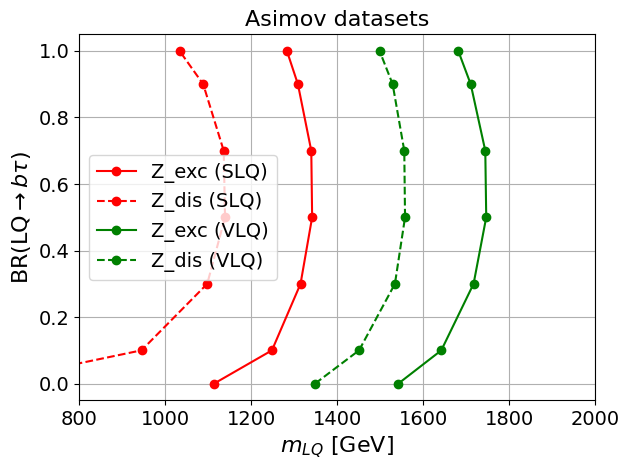

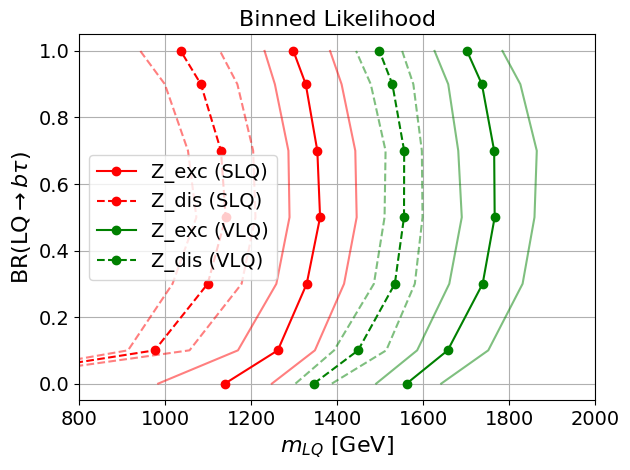

In [65]:

# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]



# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_13TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_13TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### down

In [55]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_13TeV = []
m_asimov_exc_SLQ_13TeV = []

m_asimov_dis_VLQ_13TeV = []
m_asimov_exc_VLQ_13TeV = []


m_BL_dis_SLQ_13TeV = []
m_BL_exc_SLQ_13TeV = []

m_BL_dis_VLQ_13TeV = []
m_BL_exc_VLQ_13TeV = []


m_BL_dis_SLQ_low_13TeV = []
m_BL_exc_SLQ_low_13TeV = []

m_BL_dis_VLQ_low_13TeV = []
m_BL_exc_VLQ_low_13TeV = []


m_BL_dis_SLQ_high_13TeV = []
m_BL_exc_SLQ_high_13TeV = []

m_BL_dis_VLQ_high_13TeV = []
m_BL_exc_VLQ_high_13TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_13TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_13TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_SLQ_down[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_VLQ_down[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_down, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1000)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1100)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1400)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1400)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_13TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_13TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_13TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_13TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_13TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_13TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_13TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_13TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_13TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_13TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_13TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_13TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_13TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_13TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_13TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_13TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

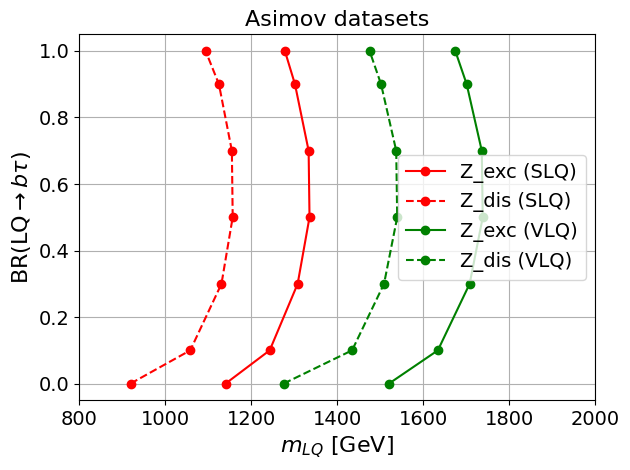

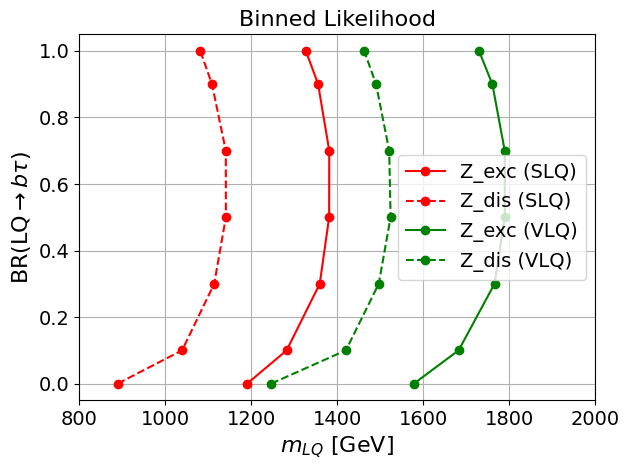

In [56]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [57]:

# SAVE

file_path = mainfolder + 'saved-results/Z13TeV_err_down.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_13TeV,
    m_asimov_dis_SLQ_13TeV,
    m_asimov_exc_VLQ_13TeV,
    m_asimov_dis_VLQ_13TeV,
    m_BL_exc_SLQ_13TeV,
    m_BL_dis_SLQ_13TeV,
    m_BL_exc_VLQ_13TeV,
    m_BL_dis_VLQ_13TeV,
    m_BL_exc_SLQ_low_13TeV,
    m_BL_dis_SLQ_low_13TeV,
    m_BL_exc_VLQ_low_13TeV,
    m_BL_dis_VLQ_low_13TeV,
    m_BL_exc_SLQ_high_13TeV,
    m_BL_dis_SLQ_high_13TeV,
    m_BL_exc_VLQ_high_13TeV,
    m_BL_dis_VLQ_high_13TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_13TeV m_asimov_dis_SLQ_13TeV m_asimov_exc_VLQ_13TeV m_asimov_dis_VLQ_13TeV m_BL_exc_SLQ_13TeV m_BL_dis_SLQ_13TeV m_BL_exc_VLQ_13TeV m_BL_dis_VLQ_13TeV m_BL_exc_SLQ_low_13TeV m_BL_dis_SLQ_low_13TeV m_BL_exc_VLQ_low_13TeV m_BL_dis_VLQ_low_13TeV m_BL_exc_SLQ_high_13TeV m_BL_dis_SLQ_high_13TeV m_BL_exc_VLQ_high_13TeV m_BL_dis_VLQ_high_13TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z13TeV_err_down.txt


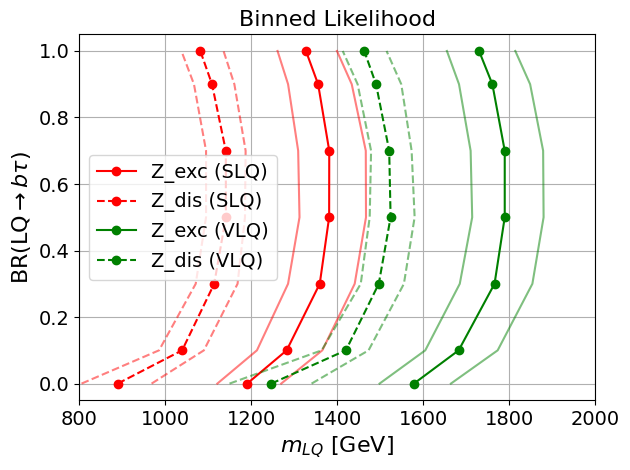

In [58]:

# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err_down.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV_down = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV_down = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV_down = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV_down = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV_down = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV_down = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV_down = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV_down = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV_down = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV_down = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV_down = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV_down = loaded_data[:, 16]






# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV_down, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV_down, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_13TeV_down, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV_down, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV_down, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV_down, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_13TeV_down, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV_down, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### up

In [59]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_13TeV = []
m_asimov_exc_SLQ_13TeV = []

m_asimov_dis_VLQ_13TeV = []
m_asimov_exc_VLQ_13TeV = []


m_BL_dis_SLQ_13TeV = []
m_BL_exc_SLQ_13TeV = []

m_BL_dis_VLQ_13TeV = []
m_BL_exc_VLQ_13TeV = []


m_BL_dis_SLQ_low_13TeV = []
m_BL_exc_SLQ_low_13TeV = []

m_BL_dis_VLQ_low_13TeV = []
m_BL_exc_VLQ_low_13TeV = []


m_BL_dis_SLQ_high_13TeV = []
m_BL_exc_SLQ_high_13TeV = []

m_BL_dis_VLQ_high_13TeV = []
m_BL_exc_VLQ_high_13TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_13TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_13TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_SLQ_up[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_VLQ_up[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_up, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1000)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1100)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1400)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1400)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_13TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_13TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_13TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_13TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_13TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_13TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_13TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_13TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_13TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_13TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_13TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_13TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_13TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_13TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_13TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_13TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

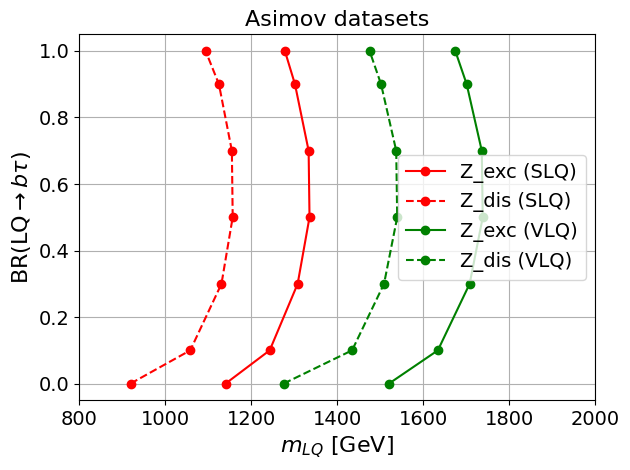

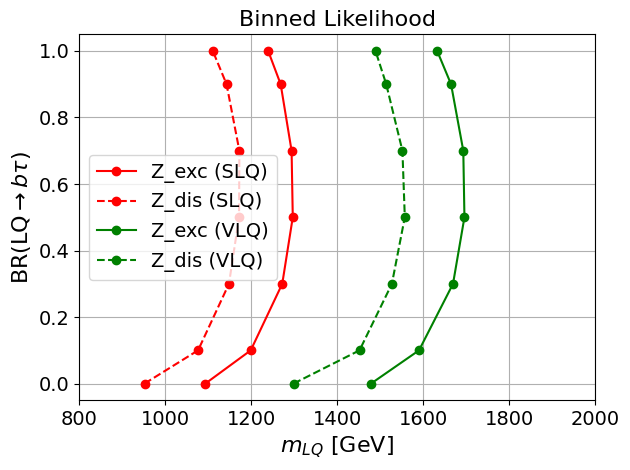

In [60]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [61]:

# SAVE

file_path = mainfolder + 'saved-results/Z13TeV_err_up.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_13TeV,
    m_asimov_dis_SLQ_13TeV,
    m_asimov_exc_VLQ_13TeV,
    m_asimov_dis_VLQ_13TeV,
    m_BL_exc_SLQ_13TeV,
    m_BL_dis_SLQ_13TeV,
    m_BL_exc_VLQ_13TeV,
    m_BL_dis_VLQ_13TeV,
    m_BL_exc_SLQ_low_13TeV,
    m_BL_dis_SLQ_low_13TeV,
    m_BL_exc_VLQ_low_13TeV,
    m_BL_dis_VLQ_low_13TeV,
    m_BL_exc_SLQ_high_13TeV,
    m_BL_dis_SLQ_high_13TeV,
    m_BL_exc_VLQ_high_13TeV,
    m_BL_dis_VLQ_high_13TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_13TeV m_asimov_dis_SLQ_13TeV m_asimov_exc_VLQ_13TeV m_asimov_dis_VLQ_13TeV m_BL_exc_SLQ_13TeV m_BL_dis_SLQ_13TeV m_BL_exc_VLQ_13TeV m_BL_dis_VLQ_13TeV m_BL_exc_SLQ_low_13TeV m_BL_dis_SLQ_low_13TeV m_BL_exc_VLQ_low_13TeV m_BL_dis_VLQ_low_13TeV m_BL_exc_SLQ_high_13TeV m_BL_dis_SLQ_high_13TeV m_BL_exc_VLQ_high_13TeV m_BL_dis_VLQ_high_13TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z13TeV_err_up.txt


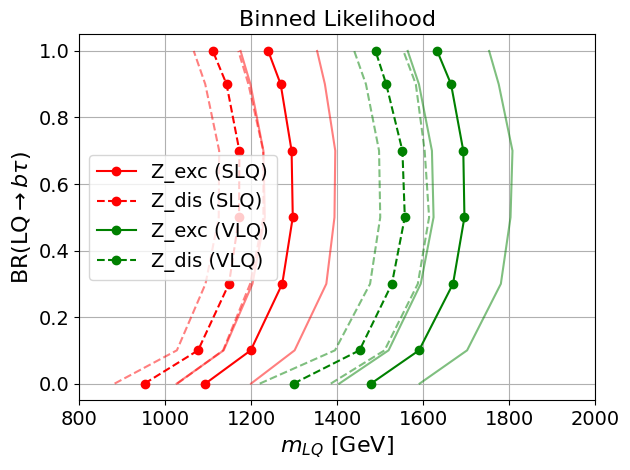

In [62]:

# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err_up.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV_up = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV_up = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV_up = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV_up = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV_up = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV_up = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV_up = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV_up = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV_up = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV_up = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV_up = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV_up = loaded_data[:, 16]






# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV_up, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV_up, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_13TeV_up, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV_up, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV_up, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV_up, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_13TeV_up, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV_up, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### no sistematics

In [63]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]

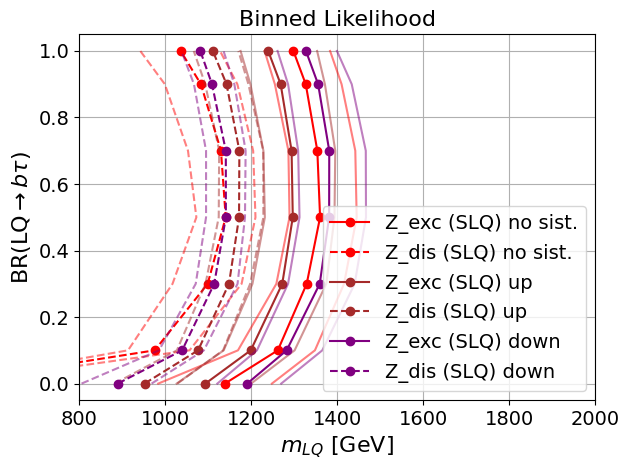

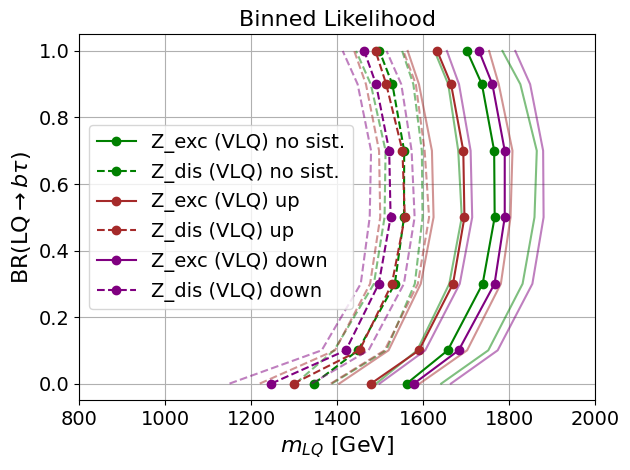

In [64]:
plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ) no sist.')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ) no sist.')
plt.plot(m_BL_dis_SLQ_low_13TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_SLQ_13TeV_up, betas, 'o-', c='brown', label='Z_exc (SLQ) up')
plt.plot(m_BL_exc_SLQ_low_13TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV_up, betas, 'o--', c='brown', label='Z_dis (SLQ) up')
plt.plot(m_BL_dis_SLQ_low_13TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_SLQ_13TeV_down, betas, 'o-', c='purple', label='Z_exc (SLQ) down')
plt.plot(m_BL_exc_SLQ_low_13TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV_down, betas, 'o--', c='purple', label='Z_dis (SLQ) down')
plt.plot(m_BL_dis_SLQ_low_13TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV_down, betas, '--', c='purple', alpha=0.5)



# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ) no sist.')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ) no sist.')
plt.plot(m_BL_dis_VLQ_low_13TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV, betas, '--', c='green', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV_up, betas, 'o-', c='brown', label='Z_exc (VLQ) up')
plt.plot(m_BL_exc_VLQ_low_13TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV_up, betas, 'o--', c='brown', label='Z_dis (VLQ) up')
plt.plot(m_BL_dis_VLQ_low_13TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV_down, betas, 'o-', c='purple', label='Z_exc (VLQ) down')
plt.plot(m_BL_exc_VLQ_low_13TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV_down, betas, 'o--', c='purple', label='Z_dis (VLQ) down')
plt.plot(m_BL_dis_VLQ_low_13TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV_down, betas, '--', c='purple', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()